# Analysis Notebook

# Setup

In [ ]:

packages <- c(
  "here",
  "gt",
  "knitr",
  "DT",
  "palmerpenguins",
  "caret",
  "cluster",
  "MASS",
  "ggpubr",
  "randomForest",
  "patchwork",
  "tidyverse",
  "dplyr",
  "ggplot2",
  "readxl",
  "writexl",
  "readr"
)

quiet_load <- function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    suppressWarnings(suppressMessages(install.packages(
      pkg,
      dependencies = TRUE
    )))
  }
  suppressPackageStartupMessages(require(
    pkg,
    character.only = TRUE,
    quietly = TRUE
  ))
  invisible(TRUE)
}

invisible(lapply(packages, quiet_load))

base_dir <- here::here()
data_dir <- file.path(base_dir, "data")
raw_data_dir <- file.path(data_dir, "raw")
der_data_dir <- file.path(data_dir, "derived")
out_dir <- file.path(base_dir, "outputs")
txt_file_dir <- file.path(base_dir, "data/raw/JUV_data")

# Set base for plots
base_theme_bw <- theme_classic() +
  theme(
    text = element_text(family = "Arial", size = 11),
    axis.title = element_text(face = "plain"),
    axis.text = element_text(face = "plain"),
    plot.title = element_text(face = "plain"),
    strip.text = element_text(face = "plain"),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.3)
  )
theme_set(base_theme_bw)

Slidecode_juv <- read_excel("data/raw/Slidecode_site_juv.xlsx")

# S1H15, S2B4, 2SF9, S3B12, S3D5, S4D1 missing from raw data files


# Data import (run only if df_ablation_juv & df_mean_juv not exist yet)

In [ ]:

# Standard atomic weight
aw <- list(
  Li7 = 6.941,
  Na23 = 22.989769,
  Mg24 = 24.305,
  Al27 = 26.9815386,
  P31 = 30.9738,
  K39 = 39.0983,
  Ca43 = 40.078,
  Mn55 = 54.938045,
  Fe57 = 55.845,
  Cu65 = 63.546,
  Zn66 = 65.39,
  Rb85 = 85.4678,
  Sr88 = 87.62,
  Ba138 = 137.327
)

# Rows to use for mean/SEM calculations
n_rows <- 197

# list all the text files in the folder
#### MAKE SURE THE FILES ARE .txt
file_names <- list.files(
  path = txt_file_dir,
  pattern = "\\.txt$",
  ignore.case = TRUE
)

# Create empty data frames to store results
df_raw_ablation_juv <- data.frame()
df_raw_mean_juv <- data.frame()

# Loop through each file and read it into a data frame
for (file_name in file_names) {
  # Construct the file path
  file_path <- file.path(txt_file_dir, file_name)

  # Read the file into a data frame
  slide <- utils::read.delim(file_path)

  # Remove rows with NAs
  slide <- stats::na.omit(slide)

  # Compute Slide_code (file name without extension)
  slide_code <- tools::file_path_sans_ext(basename(file_name))

  # Make new column with and convert from g/g to mmol/molCa results
  slide$`Li7_mmol_molCa` <- 100100 * slide$Li_g_g_m7 / aw$Li7
  slide$`Na23_mmol_molCa` <- 100100 * slide$Na_g_g_m23 / aw$Na23
  slide$`Mg24_mmol_molCa` <- 100100 * slide$Mg_g_g_m24 / aw$Mg24
  slide$`Al27_mmol_molCa` <- 100100 * slide$Al_g_g_m27 / aw$Al27
  slide$`P31_mmol_molCa` <- 100100 * slide$P_g_g_m31 / aw$P31
  slide$`K39_mmol_molCa` <- 100100 * slide$K_g_g_m39 / aw$K39
  slide$`Mn55_mmol_molCa` <- 100100 * slide$Mn_g_g_m55 / aw$Mn55
  slide$`Fe57_mmol_molCa` <- 100100 * slide$Fe_g_g_m57 / aw$Fe57
  slide$`Cu65_mmol_molCa` <- 100100 * slide$Cu_g_g_m65 / aw$Cu65
  slide$`Zn66_mmol_molCa` <- 100100 * slide$Zn_g_g_m66 / aw$Zn66
  slide$`Rb85_mmol_molCa` <- 100100 * slide$Rb_g_g_m85 / aw$Rb85
  slide$`Sr88_mmol_molCa` <- 100100 * slide$Sr_g_g_m88 / aw$Sr88
  slide$`Ba138_mmol_molCa` <- 100100 * slide$Ba_g_g_m138 / aw$Ba138

  # Add columns for the file name and code
  slide$File <- file_name
  slide$Slide_code <- slide_code

  # Calculate means of mmol/molCa results
  meanLi7 <- mean(slide[1:n_rows, "Li7_mmol_molCa"], na.rm = TRUE)
  meanNa23 <- mean(slide[1:n_rows, "Na23_mmol_molCa"], na.rm = TRUE)
  meanMg24 <- mean(slide[1:n_rows, "Mg24_mmol_molCa"], na.rm = TRUE)
  meanAl27 <- mean(slide[1:n_rows, "Al27_mmol_molCa"], na.rm = TRUE)
  meanP31 <- mean(slide[1:n_rows, "P31_mmol_molCa"], na.rm = TRUE)
  meanK39 <- mean(slide[1:n_rows, "K39_mmol_molCa"], na.rm = TRUE)
  meanMn55 <- mean(slide[1:n_rows, "Mn55_mmol_molCa"], na.rm = TRUE)
  meanFe57 <- mean(slide[1:n_rows, "Fe57_mmol_molCa"], na.rm = TRUE)
  meanCu65 <- mean(slide[1:n_rows, "Cu65_mmol_molCa"], na.rm = TRUE)
  meanZn66 <- mean(slide[1:n_rows, "Zn66_mmol_molCa"], na.rm = TRUE)
  meanRb85 <- mean(slide[1:n_rows, "Rb85_mmol_molCa"], na.rm = TRUE)
  meanSr88 <- mean(slide[1:n_rows, "Sr88_mmol_molCa"], na.rm = TRUE)
  meanBa138 <- mean(slide[1:n_rows, "Ba138_mmol_molCa"], na.rm = TRUE)

  # Calculate standard error of the mean (SEM)
  semLi7 <- stats::sd(slide[1:n_rows, "Li7_mmol_molCa"], na.rm = TRUE) /
    sqrt(n_rows)
  semNa23 <- stats::sd(slide[1:n_rows, "Na23_mmol_molCa"], na.rm = TRUE) /
    sqrt(n_rows)
  semMg24 <- stats::sd(slide[1:n_rows, "Mg24_mmol_molCa"], na.rm = TRUE) /
    sqrt(n_rows)
  semAl27 <- stats::sd(slide[1:n_rows, "Al27_mmol_molCa"], na.rm = TRUE) /
    sqrt(n_rows)
  semP31 <- stats::sd(slide[1:n_rows, "P31_mmol_molCa"], na.rm = TRUE) /
    sqrt(n_rows)
  semK39 <- stats::sd(slide[1:n_rows, "K39_mmol_molCa"], na.rm = TRUE) /
    sqrt(n_rows)
  semMn55 <- stats::sd(slide[1:n_rows, "Mn55_mmol_molCa"], na.rm = TRUE) /
    sqrt(n_rows)
  semFe57 <- stats::sd(slide[1:n_rows, "Fe57_mmol_molCa"], na.rm = TRUE) /
    sqrt(n_rows)
  semCu65 <- stats::sd(slide[1:n_rows, "Cu65_mmol_molCa"], na.rm = TRUE) /
    sqrt(n_rows)
  semZn66 <- stats::sd(slide[1:n_rows, "Zn66_mmol_molCa"], na.rm = TRUE) /
    sqrt(n_rows)
  semRb85 <- stats::sd(slide[1:n_rows, "Rb85_mmol_molCa"], na.rm = TRUE) /
    sqrt(n_rows)
  semSr88 <- stats::sd(slide[1:n_rows, "Sr88_mmol_molCa"], na.rm = TRUE) /
    sqrt(n_rows)
  semBa138 <- stats::sd(slide[1:n_rows, "Ba138_mmol_molCa"], na.rm = TRUE) /
    sqrt(n_rows)

  # Add the data frame to the cumulative raw results
  df_raw_ablation_juv <- rbind(df_raw_ablation_juv, slide)

  # Create a data frame with means and SEM for this file and append
  df_raw_mean_juv <- rbind(
    df_raw_mean_juv,
    data.frame(
      file_name = file_name,
      Slide_code = slide_code,
      meanLi7 = meanLi7,
      semLi7 = semLi7,
      meanNa23 = meanNa23,
      semNa23 = semNa23,
      meanMg24 = meanMg24,
      semMg24 = semMg24,
      meanAl27 = meanAl27,
      semAl27 = semAl27,
      meanP31 = meanP31,
      semP31 = semP31,
      meanK39 = meanK39,
      semK39 = semK39,
      meanMn55 = meanMn55,
      semMn55 = semMn55,
      meanFe57 = meanFe57,
      semFe57 = semFe57,
      meanCu65 = meanCu65,
      semCu65 = semCu65,
      meanZn66 = meanZn66,
      semZn66 = semZn66,
      meanRb85 = meanRb85,
      semRb85 = semRb85,
      meanSr88 = meanSr88,
      semSr88 = semSr88,
      meanBa138 = meanBa138,
      semBa138 = semBa138,
      stringsAsFactors = FALSE
    )
  )
}

# comebine the slide info with the df's
df_raw_ablation_juv <- df_raw_ablation_juv %>%
  mutate(Slide_code = as.character(Slide_code))
df_raw_mean_juv <- df_raw_mean_juv %>%
  mutate(Slide_code = as.character(Slide_code))
Slidecode_juv <- Slidecode_juv %>% mutate(Slide_code = as.character(Slide_code))

df_ablation_juv <- df_raw_ablation_juv %>%
  left_join(Slidecode_juv, by = "Slide_code")

df_mean_juv <- df_raw_mean_juv %>%
  left_join(Slidecode_juv, by = "Slide_code")

# filter out ablations with valerite and unstable Ca43_CPS
df_ablation_juv <- df_ablation_juv %>%
  dplyr::filter(
    !Slide_code %in% c("S3F12", "S1F2", "S3D9", "S2C11", "S3G9", "S4E3")
  ) #valerite "S2C11", "S3G9", "S4E3"

df_mean_juv <- df_mean_juv %>%
  dplyr::filter(
    !Slide_code %in% c("S3F12", "S1F2", "S3D9", "S2C11", "S3G9", "S4E3")
  ) #valerite "S2C11", "S3G9", "S4E3"

# save the df's
write.csv(
  df_ablation_juv,
  file = file.path(der_data_dir, "df_ablation_juv.csv"),
  row.names = FALSE
)
write.csv(
  df_mean_juv,
  file = file.path(der_data_dir, "df_mean_juv.csv"),
  row.names = FALSE
)


# Plot the raw ablations

In [ ]:

df_ablation_juv <- read_csv("data/derived/df_ablation_juv.csv")


Rows: 117415 Columns: 41
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6): File, Slide_code, Site, District, River, Life_stage
dbl (35): ElapsedTime_s, Ca43_CPS, IntStdWv, Li_g_g_m7, Na_g_g_m23, Mg_g_g_m...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

Rows: 595 Columns: 38
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6): file_name, Slide_code, Site, District, River, Life_stage
dbl (32): meanLi7, semLi7, meanNa23, semNa23, meanMg24, semMg24, meanAl27, s...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

# Element selection

In [ ]:

# Set vars
vars <- c(
  "meanLi7",
  "meanNa23",
  "meanMg24",
  "meanAl27",
  "meanP31",
  "meanK39",
  "meanMn55",
  "meanFe57",
  "meanCu65",
  "meanZn66",
  "meanRb85",
  "meanSr88",
  "meanBa138"
)

df_mean_juv_clean <- df_mean_juv %>%
  select(Slide_code, Year, Site, all_of(vars)) %>%
  mutate(across(c(Slide_code, Year, Site), as.factor))

element_data <- select(df_mean_juv_clean, all_of(vars))

# MANOVA for Year
manova_year <- manova(as.matrix(element_data) ~ Year, data = df_mean_juv_clean)

# MANOVA for Site
manova_site <- manova(as.matrix(element_data) ~ Site, data = df_mean_juv_clean)

# ANOVA for each element
anova_row <- function(v, f) {
  a <- anova(aov(reformulate(f, v), df_mean_juv_clean))
  if (f %in% rownames(a)) {
    tibble(
      Variables = v,
      Factor = f,
      Df = a[f, "Df"],
      `Sum Sq` = a[f, "Sum Sq"],
      `Mean Sq` = a[f, "Mean Sq"],
      `F value` = a[f, "F value"],
      p_value = a[f, "Pr(>F)"]
    )
  } else {
    tibble(
      Variables = v,
      Factor = f,
      Df = NA_integer_,
      `Sum Sq` = NA_real_,
      `Mean Sq` = NA_real_,
      `F value` = NA_real_,
      p_value = NA_real_
    )
  }
}

anova_table <- crossing(Variables = vars, Factor = c("Year", "Site")) %>%
  pmap_dfr(~ anova_row(..1, ..2)) %>%
  mutate(
    Variables = factor(Variables, levels = vars),
    Factor = factor(Factor, levels = c("Year", "Site"))
  ) %>%
  arrange(Variables, Factor)

element_selection_table <- anova_table %>%
  select(Variables, Factor, p_value, `F value`) %>%
  pivot_wider(
    names_from = Factor,
    values_from = c(p_value, `F value`),
    names_sep = "_"
  ) %>%
  mutate(
    p_site_adj = p.adjust(p_value_Site, "BH"),
    p_year_adj = p.adjust(p_value_Year, "BH"),
    spatially_variable = p_site_adj < 0.05,
    temporally_stable = p_year_adj >= 0.05,
    classification = case_when(
      spatially_variable &
        temporally_stable ~ "Spatially variable & temporally stable",
      spatially_variable ~ "Spatially variable, NOT temporally stable",
      temporally_stable ~ "Temporally stable, NOT spatially variable",
      TRUE ~ "No clear effect"
    )
  )

# Prepare display table with nice element names
element_selection_display <- element_selection_table %>%
  mutate(
    Element = case_when(
      Variables == "meanLi7" ~ "Li⁷",
      Variables == "meanNa23" ~ "Na²³",
      Variables == "meanMg24" ~ "Mg²⁴",
      Variables == "meanAl27" ~ "Al²⁷",
      Variables == "meanP31" ~ "P³¹",
      Variables == "meanK39" ~ "K³⁹",
      Variables == "meanMn55" ~ "Mn⁵⁵",
      Variables == "meanFe57" ~ "Fe⁵⁷",
      Variables == "meanCu65" ~ "Cu⁶⁵",
      Variables == "meanZn66" ~ "Zn⁶⁶",
      Variables == "meanRb85" ~ "Rb⁸⁵",
      Variables == "meanSr88" ~ "Sr⁸⁸",
      Variables == "meanBa138" ~ "Ba¹³⁸",
      TRUE ~ as.character(Variables)
    )
  ) %>%
  select(
    Element,
    `F-value (Site)` = `F value_Site`,
    `p-value (Site)` = p_site_adj,
    `F-value (Year)` = `F value_Year`,
    `p-value (Year)` = p_year_adj,
    `Spatial Variability` = spatially_variable,
    `Temporal Stability` = temporally_stable,
    Classification = classification
  )

# Save CSV (without fancy element names for easier processing)
write.csv(
  element_selection_table %>%
    mutate(Element = gsub("mean", "", Variables)) %>%
    select(
      Element,
      `F value_Site`,
      p_site_adj,
      `F value_Year`,
      p_year_adj,
      classification
    ),
  file = file.path(out_dir, "element_selection_table.csv"),
  row.names = FALSE
)

# Create interactive table with color coding
datatable(
  element_selection_display,
  options = list(
    pageLength = 13,
    scrollX = TRUE,
    dom = 't', # Hide search box and pagination for this small table
    columnDefs = list(
      list(className = 'dt-center', targets = 1:7)
    )
  ),
  rownames = FALSE
) %>%
  formatRound(columns = c('F-value (Site)', 'F-value (Year)'), digits = 2) %>%
  formatSignif(columns = c('p-value (Site)', 'p-value (Year)'), digits = 3) %>%
  formatStyle(
    'p-value (Site)',
    backgroundColor = styleInterval(0.05, c('#d4edda', '#f8d7da')), # Green if < 0.05, red if >= 0.05
    fontWeight = 'bold'
  ) %>%
  formatStyle(
    'p-value (Year)',
    backgroundColor = styleInterval(0.05, c('#f8d7da', '#d4edda')), # Red if < 0.05, green if >= 0.05
    fontWeight = 'bold'
  ) %>%
  formatStyle(
    'Spatial Variability',
    backgroundColor = styleEqual(c(TRUE, FALSE), c('#d4edda', '#f8d7da'))
  ) %>%
  formatStyle(
    'Temporal Stability',
    backgroundColor = styleEqual(c(TRUE, FALSE), c('#d4edda', '#f8d7da'))
  ) %>%
  formatStyle(
    'Classification',
    backgroundColor = styleEqual(
      c(
        "Spatially variable & temporally stable",
        "Spatially variable, NOT temporally stable",
        "Temporally stable, NOT spatially variable",
        "No clear effect"
      ),
      c('#d4edda', '#fff3cd', '#d1ecf1', '#f8d7da')
    ),
    fontWeight = styleEqual(
      "Spatially variable & temporally stable",
      'bold'
    )
  )


In [ ]:

element_selection_display |>
  dplyr::mutate(
    `Spatial Variability` = ifelse(`Spatial Variability`, "Yes", "No"),
    `Temporal Stability` = ifelse(`Temporal Stability`, "Yes", "No")
  ) |>
  knitr::kable()


  -----------------------------------------------------------------------------------------------------------
  Element         F-value     p-value      F-value     p-value Spatial       Temporal    Classification
                   (Site)      (Site)       (Year)      (Year) Variability   Stability   
  --------- ------------- ----------- ------------ ----------- ------------- ----------- --------------------
  Li⁷           8.1182464   0.0000000   13.8239985   0.0000000 Yes           No          Spatially variable,
                                                                                         NOT temporally
                                                                                         stable

  Na²³          3.5582822   0.0000009   85.3999340   0.0000000 Yes           No          Spatially variable,
                                                                                         NOT temporally
                                                                                         stable

  Mg²⁴          0.7936608   0.7159571   10.3274679   0.0000020 No            No          No clear effect

  Al²⁷          1.4529399   0.1141095    2.5116387   0.0750397 No            Yes         Temporally stable,
                                                                                         NOT spatially
                                                                                         variable

  P³¹           3.5794384   0.0000009   23.4968634   0.0000000 Yes           No          Spatially variable,
                                                                                         NOT temporally
                                                                                         stable

  K³⁹           4.8398620   0.0000000   48.2471412   0.0000000 Yes           No          Spatially variable,
                                                                                         NOT temporally
                                                                                         stable

  Mn⁵⁵         31.5106270   0.0000000    2.0809712   0.1100530 Yes           Yes         Spatially variable &
                                                                                         temporally stable

  Fe⁵⁷          7.8072613   0.0000000   32.8983095   0.0000000 Yes           No          Spatially variable,
                                                                                         NOT temporally
                                                                                         stable

  Cu⁶⁵          1.1221396   0.3505214   22.0018920   0.0000000 No            No          No clear effect

  Zn⁶⁶          2.2680293   0.0021902    3.9891065   0.0113918 Yes           No          Spatially variable,
                                                                                         NOT temporally
                                                                                         stable

  Rb⁸⁵         34.4225136   0.0000000   26.7456006   0.0000000 Yes           No          Spatially variable,
                                                                                         NOT temporally
                                                                                         stable

  Sr⁸⁸        118.8171174   0.0000000    2.4300983   0.0759794 Yes           Yes         Spatially variable &
                                                                                         temporally stable

  Ba¹³⁸        77.7910301   0.0000000    0.9060693   0.4378081 Yes           Yes         Spatially variable &
                                                                                         temporally stable
  -----------------------------------------------------------------------------------------------------------


## Element selection I

``` r

vars <- c(
  "meanLi7",
  "meanNa23",
  "meanMg24",
  "meanAl27",
  "meanP31",
  "meanK39",
  "meanMn55",
  "meanFe57",
  "meanCu65",
  "meanZn66",
  "meanRb85",
  "meanSr88",
  "meanBa138"
)

df_mean_juv_clean <- df_mean_juv %>%
  dplyr::select(Slide_code, Year, Site, dplyr::all_of(vars)) %>%
  dplyr::mutate(dplyr::across(c(Slide_code, Year, Site), as.factor))

element_data <- dplyr::select(df_mean_juv_clean, dplyr::all_of(vars))

manova_year <- stats::manova(
  as.matrix(element_data) ~ Year,
  data = df_mean_juv_clean
)
summary(manova_year)
```

               Df  Pillai approx F num Df den Df    Pr(>F)    
    Year        3 0.98679   21.906     39   1743 < 2.2e-16 ***
    Residuals 591                                             
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

``` r

manova_site <- stats::manova(
  as.matrix(element_data) ~ Site,
  data = df_mean_juv_clean
)
summary(manova_site)
```

               Df Pillai approx F num Df den Df    Pr(>F)    
    Site       19 3.4712   11.024    247   7475 < 2.2e-16 ***
    Residuals 575                                            
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

``` r

anova_row <- function(v, f) {
  a <- stats::anova(stats::aov(stats::reformulate(f, v), df_mean_juv_clean))
  if (f %in% rownames(a)) {
    tibble::tibble(
      Variables = v,
      Factor = f,
      Df = a[f, "Df"],
      `Sum Sq` = a[f, "Sum Sq"],
      `Mean Sq` = a[f, "Mean Sq"],
      `F value` = a[f, "F value"],
      p_value = a[f, "Pr(>F)"]
    )
  } else {
    tibble::tibble(
      Variables = v,
      Factor = f,
      Df = NA_integer_,
      `Sum Sq` = NA_real_,
      `Mean Sq` = NA_real_,
      `F value` = NA_real_,
      p_value = NA_real_
    )
  }
}

anova_table <- tidyr::crossing(Variables = vars, Factor = c("Year", "Site")) %>%
  purrr::pmap_dfr(~ anova_row(..1, ..2)) %>%
  dplyr::mutate(
    Variables = factor(Variables, levels = vars),
    Factor = factor(Factor, levels = c("Year", "Site"))
  ) %>%
  dplyr::arrange(Variables, Factor)

element_selection_table <- anova_table %>%
  dplyr::select(Variables, Factor, p_value, `F value`) %>%
  tidyr::pivot_wider(
    names_from = Factor,
    values_from = c(p_value, `F value`),
    names_sep = "_"
  ) %>%
  dplyr::mutate(
    p_site_adj = p.adjust(p_value_Site, "BH"),
    p_year_adj = p.adjust(p_value_Year, "BH"),
    spatially_variable = p_site_adj < 0.05,
    temporally_stable = p_year_adj >= 0.05,
    classification = dplyr::case_when(
      spatially_variable &
        temporally_stable ~ "Spatially variable & temporally stable",
      spatially_variable ~ "Spatially variable, NOT temporally stable",
      temporally_stable ~ "Temporally stable, NOT spatially variable",
      TRUE ~ "No clear effect"
    )
  )
```

## Element selection II

``` r

# Two-way ANOVA per variable
alpha <- 0.05

order_vars <- c(
  "meanLi7",
  "meanNa23",
  "meanMg24",
  "meanAl27",
  "meanP31",
  "meanK39",
  "meanMn55",
  "meanFe57",
  "meanCu65",
  "meanZn66",
  "meanRb85",
  "meanSr88",
  "meanBa138"
)

aov2_row <- function(response, data) {
  fit <- stats::aov(
    stats::as.formula(paste(response, "~ Site * Year")),
    data = data
  )
  tab <- stats::anova(fit)
  rn <- rownames(tab)
  get <- function(term, col) if (term %in% rn) tab[term, col] else NA

  tibble::tibble(
    Variables = response,
    p_site = as.numeric(get("Site", "Pr(>F)")),
    p_year = as.numeric(get("Year", "Pr(>F)")),
    p_site_year = as.numeric(get("Site:Year", "Pr(>F)")),
    F_site = as.numeric(get("Site", "F value")),
    F_year = as.numeric(get("Year", "F value")),
    F_site_year = as.numeric(get("Site:Year", "F value"))
  )
}

twoway_tbl <- dplyr::bind_rows(lapply(
  order_vars,
  aov2_row,
  data = df_mean_juv_clean
)) %>%
  mutate(
    p_site_BH = p.adjust(p_site, method = "BH"),
    p_year_BH = p.adjust(p_year, method = "BH"),
    p_site_year_BH = p.adjust(p_site_year, method = "BH"),
    spatially_variable = p_site_BH < alpha,
    temporally_stable = (p_year_BH >= alpha) & (p_site_year_BH >= alpha),
    classification = dplyr::case_when(
      spatially_variable &
        temporally_stable ~ "Spatially variable & temporally stable",
      spatially_variable &
        !temporally_stable ~ "Spatially variable, NOT temporally stable",
      !spatially_variable &
        temporally_stable ~ "Temporally stable, NOT spatially variable",
      TRUE ~ "No clear effect"
    )
  ) %>%
  mutate(Variables = factor(Variables, levels = order_vars)) %>%
  arrange(Variables)

#twoway_tbl
```

# Main elements plot

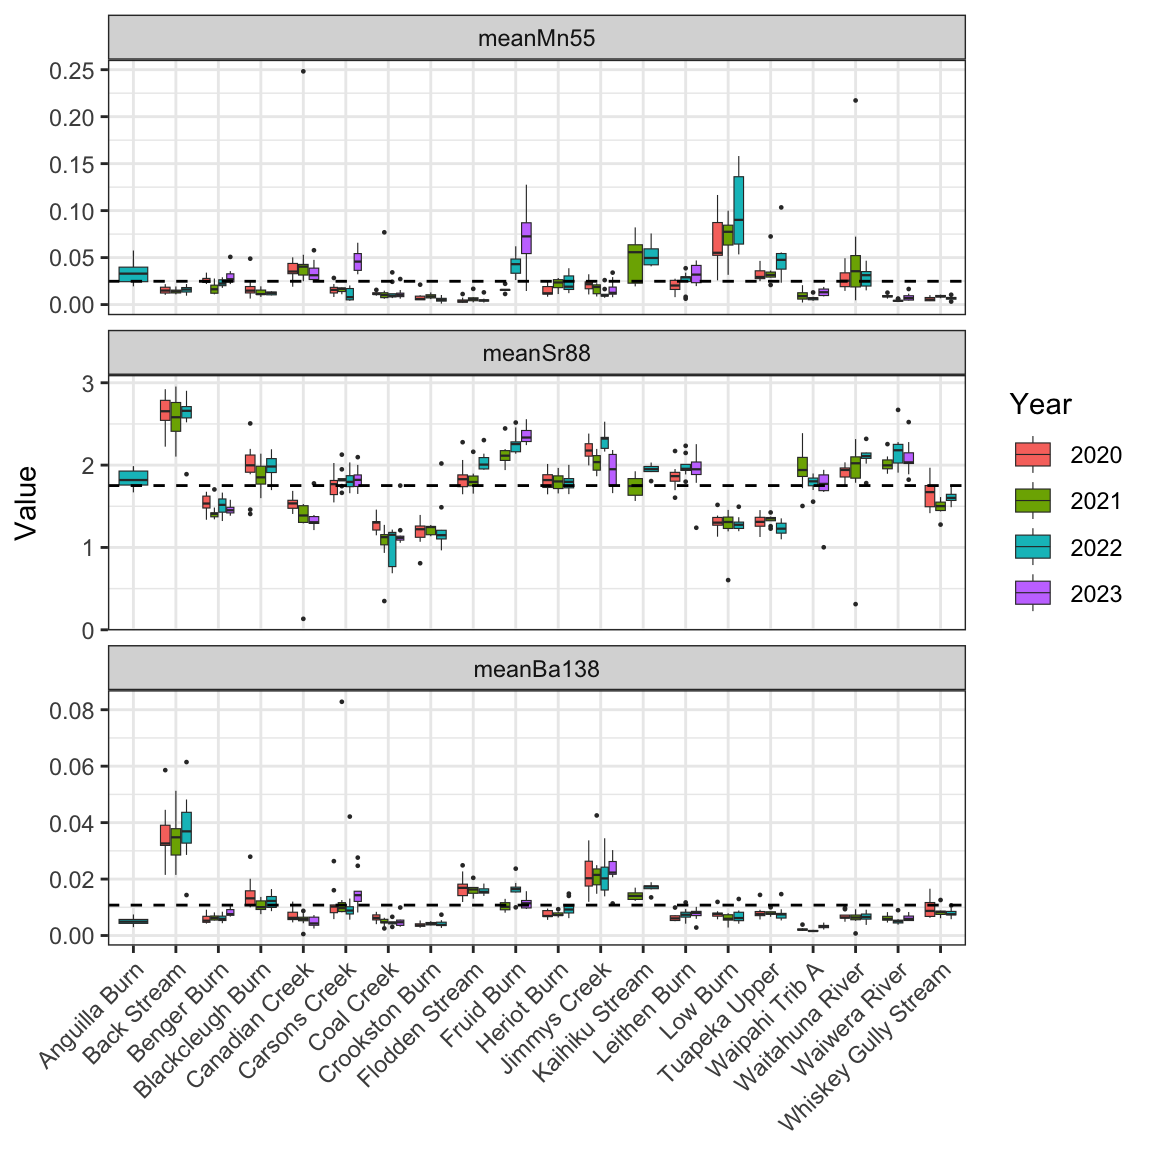

In [ ]:

vars_main <- c("meanMn55", "meanSr88", "meanBa138")

# Combine all variables into a single data frame for faceting
df_mean_juv_long_main <- df_mean_juv_clean %>%
  dplyr::select(Slide_code, Year, Site, dplyr::all_of(vars_main)) %>%
  tidyr::pivot_longer(
    cols = dplyr::all_of(vars_main),
    names_to = "Variable",
    values_to = "Value"
  ) %>%
  dplyr::mutate(Variable = factor(Variable, levels = vars_main))

# Calculate the mean for each variable
mean_values_main <- df_mean_juv_long_main %>%
  group_by(Variable) %>%
  summarise(mean_values_main = mean(Value, na.rm = TRUE))

# Create the plot
main_elements <- ggplot(
  df_mean_juv_long_main,
  aes(Site, Value, fill = as.factor(Year))
) +
  geom_boxplot(size = 0.2, outlier.shape = 16, outlier.size = .5) +
  geom_hline(
    data = mean_values_main,
    aes(yintercept = mean_values_main),
    linetype = 2,
  ) + # Mean line for each variable
  facet_wrap(~Variable, scales = "free_y", ncol = 1) + # Facet by the variable names
  theme_bw() +
  theme(
    axis.title.x = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1),
    strip.text.x = element_text(),
    labs(fill = "Year")
  ) +
  guides(fill = guide_legend(title = "Year"))

ggsave(
  main_elements,
  file = file.path(out_dir, "fig-main-elements.png"),
  width = 6,
  height = 6,
  bg = "white",
  dpi = 600
)

main_elements


# Other element figure

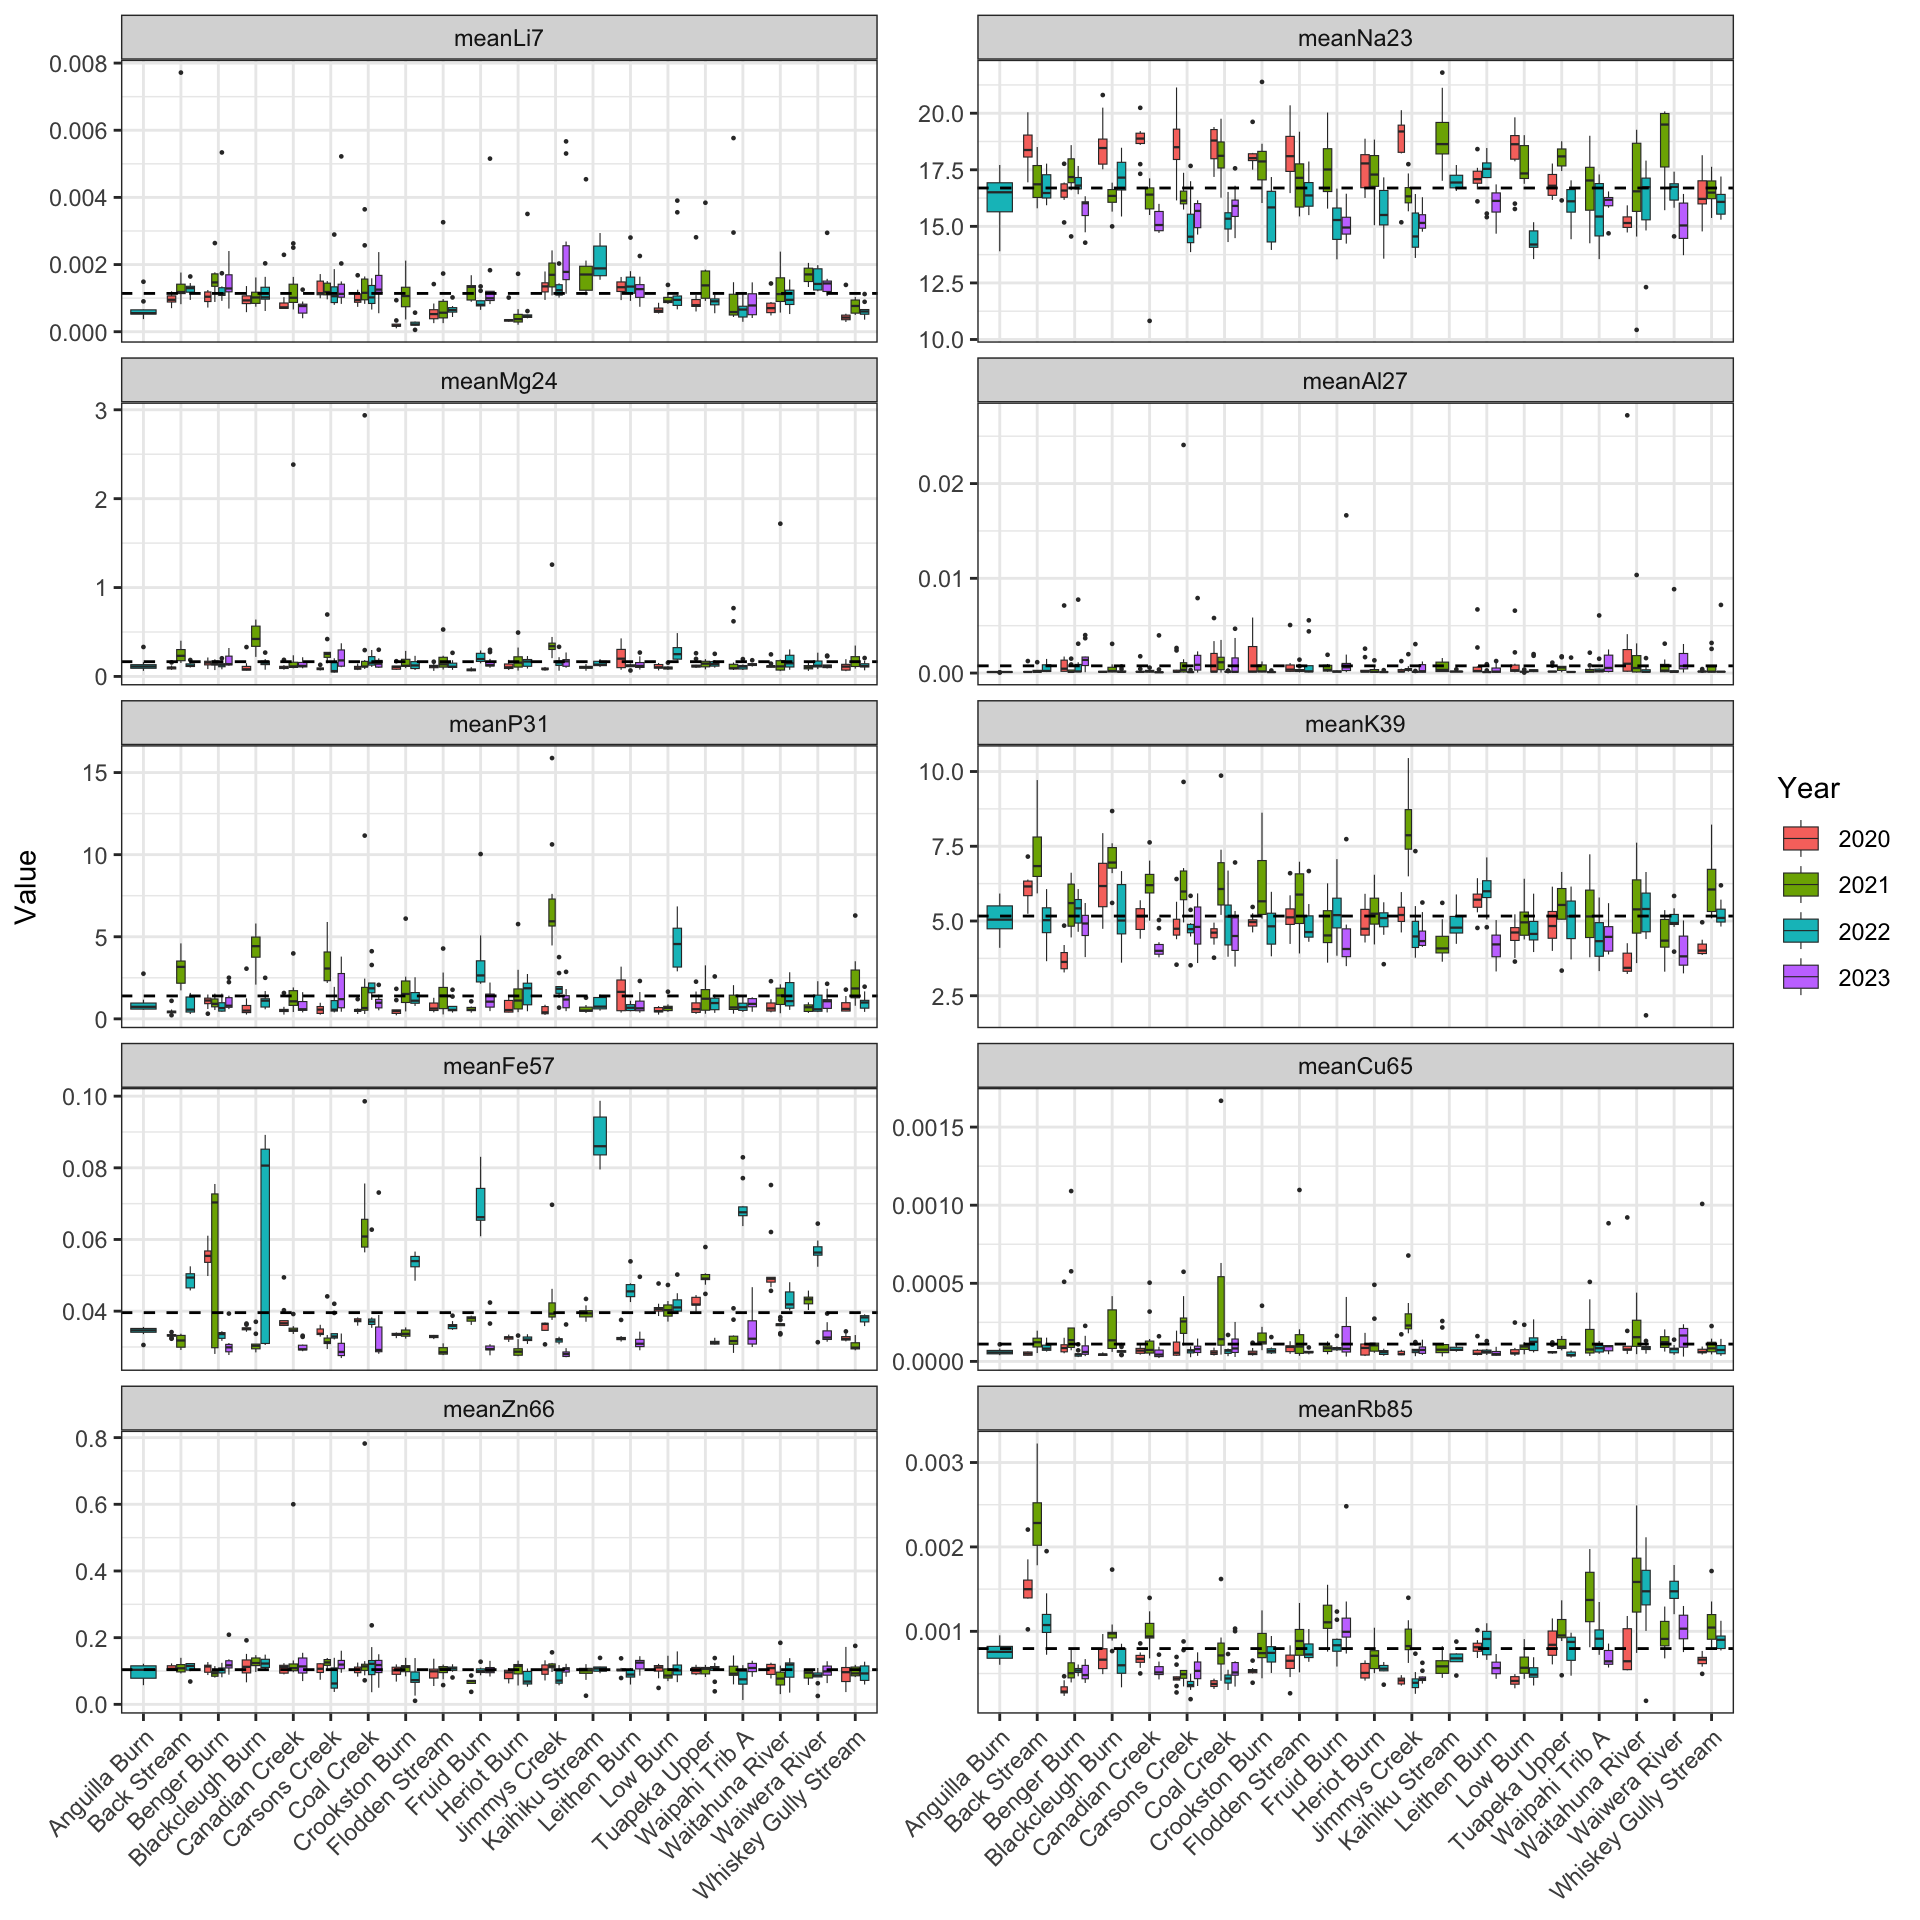

In [ ]:

vars_other <- c(
  "meanLi7",
  "meanNa23",
  "meanMg24",
  "meanAl27",
  "meanP31",
  "meanK39",
  "meanFe57",
  "meanCu65",
  "meanZn66",
  "meanRb85"
)

# make long format of the other elements
df_mean_juv_long_other <- df_mean_juv_clean %>%
  dplyr::select(Slide_code, Year, Site, dplyr::all_of(vars_other)) %>%
  tidyr::pivot_longer(
    cols = dplyr::all_of(vars_other),
    names_to = "Variable",
    values_to = "Value"
  ) %>%
  dplyr::mutate(Variable = factor(Variable, levels = vars_other))

# Calculate the mean for each variable
mean_values_other <- df_mean_juv_long_other %>%
  group_by(Variable) %>%
  summarise(mean_values_other = mean(Value, na.rm = TRUE))

# Create the plot
other_elements <- ggplot(
  df_mean_juv_long_other,
  aes(Site, Value, fill = as.factor(Year))
) + #
  geom_boxplot(size = 0.2, outlier.shape = 16, outlier.size = .5) +
  geom_hline(
    data = mean_values_other,
    aes(yintercept = mean_values_other),
    linetype = 2,
  ) + # Mean line for each variable
  facet_wrap(~Variable, scales = "free_y", ncol = 2) + # Facet by the variable names
  theme_bw() +
  theme(
    axis.title.x = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1),
    strip.text.x = element_text(),
    labs(fill = "Year")
  ) +
  guides(fill = guide_legend(title = "Year"))

ggsave(
  other_elements,
  file = file.path(out_dir, "fig-other-elements.png"),
  width = 10,
  height = 10,
  dpi = 600
)

other_elements


# RF analysis

In [ ]:

df_mean_juv_clean_main <- df_mean_juv_clean %>%
  dplyr::select(Site, dplyr::all_of(vars_main))

# Fixed seed: randomForest() bootstrap-samples and picks split variables at
# random, so accuracy drifts a little on every re-render without this. Added
# after publication — results are stable from here on, but this exact seed
# was not used for the numbers printed in the published article.
set.seed(42)
rf_model <- randomForest(
  Site ~ .,
  data = df_mean_juv_clean_main,
  ntree = 400,
  importance = TRUE
)

conf_matrix <- rf_model$confusion

correct_predictions <- sum(diag(conf_matrix))
total_predictions <- sum(conf_matrix)
accuracy_rf <- correct_predictions / total_predictions

# Remove the class.error column for display
conf_display_rf <- conf_matrix[, !colnames(conf_matrix) %in% "class.error"]

# Add class error as % column
class_error_pct <- paste0(round(conf_matrix[, "class.error"] * 100, 1), "%")

conf_display_rf <- cbind(
  as.data.frame(conf_display_rf),
  `Class error` = class_error_pct
)

write.csv(
  conf_matrix,
  file = file.path(out_dir, "rf_conf_matrix.csv"),
  row.names = TRUE
)

knitr::kable(conf_display_rf, rownames_to_stub = TRUE)


  ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                  Anguilla     Back   Benger   Blackcleugh   Canadian   Carsons    Coal   Crookston   Flodden   Fruid   Heriot   Jimmys   Kaihiku   Leithen    Low   Tuapeka   Waipahi   Waitahuna   Waiwera   Whiskey Class
                      Burn   Stream     Burn          Burn      Creek     Creek   Creek        Burn    Stream    Burn     Burn    Creek    Stream      Burn   Burn     Upper    Trib A       River     River     Gully error
                                                                                                                                                                                                                Stream 
  ------------- ---------- -------- -------- ------------- ---------- --------- ------- ----------- --------- ------- -------- -------- --------- --------- ------ --------- --------- ----------- --------- --------- -------
  Anguilla Burn          2        0        0             0          0         0       0           0         0       0        0        0         0         1      0         0         2           6         0         0 81.8%

  Back Stream            0       25        0             0          0         0       0           0         0       0        0        5         0         0      0         0         0           0         0         0 16.7%

  Benger Burn            0        0       25             0          7         1       1           0         0       0        4        0         0         0      0         1         0           0         0         0 35.9%

  Blackcleugh            0        1        0            12          0         5       0           0         0       3        2        3         1         0      1         0         0           0         1         1 60%
  Burn                                                                                                                                                                                                                 

  Canadian               0        0        8             0         16         2       1           0         0       0        0        0         0         1      2         1         0           1         0         0 50%
  Creek                                                                                                                                                                                                                

  Carsons Creek          0        0        2             5          0         8       0           0         1       0        5        4         5         2      0         0         0           2         2         3 79.5%

  Coal Creek             1        0        0             0          1         0      29           3         0       0        0        0         0         0      2         1         0           0         0         3 27.5%

  Crookston              0        0        1             0          0         0       9          15         0       0        0        0         0         0      0         0         0           0         1         1 44.4%
  Burn                                                                                                                                                                                                                 

  Flodden                0        0        0             1          0         2       0           0        24       0        0        1         0         0      0         0         0           0         0         1 17.2%
  Stream                                                                                                                                                                                                               

  Fruid Burn             0        1        0             3          0         0       0           0         0      19        1        3         0         1      0         0         0           0         0         0 32.1%

  Heriot Burn            0        0        4             2          0        11       0           0         0       0        9        0         0         3      0         0         0           0         1         0 70%

  Jimmys Creek           0        1        0             2          0         1       0           0         1       3        0       32         0         0      0         0         0           0         0         1 22%

  Kaihiku                0        0        0             0          0         4       0           0         0       0        0        0        11         0      1         0         0           0         0         0 31.2%
  Stream                                                                                                                                                                                                               

  Leithen Burn           3        0        1             0          2         1       0           0         0       2        5        0         0         8      0         0         0           4         4         0 73.3%

  Low Burn               0        0        0             0          3         0       1           0         0       0        0        0         1         0     21         4         0           0         0         0 30%

  Tuapeka Upper          0        0        3             0          2         0       1           0         0       0        0        0         0         0      3        20         0           0         0         0 31%

  Waipahi Trib           0        0        1             0          0         0       1           0         0       0        0        0         0         0      0         0        24           0         1         0 11.1%
  A                                                                                                                                                                                                                    

  Waitahuna              3        0        0             0          1         1       0           0         0       0        0        0         0         9      0         0         0          14         1         0 51.7%
  River                                                                                                                                                                                                                

  Waiwera River          0        0        0             0          0         0       0           0         0       0        1        0         0         2      0         0         1           1        23         0 17.9%

  Whiskey Gully          0        0        0             0          0         2       1           0         3       0        0        0         0         0      0         0         0           0         0        24 20%
  Stream                                                                                                                                                                                                               
  ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# LDA analysis

In [ ]:

# Build a single working frame
df_main_full <- df_mean_juv_clean %>%
  dplyr::select(Slide_code, Year, Site, dplyr::all_of(vars_main)) %>%
  tidyr::drop_na(dplyr::all_of(vars_main))

df_mean_juv_clean_main <- df_main_full %>%
  dplyr::select(Site, dplyr::all_of(vars_main))

# LOOCV
num_folds <- nrow(df_mean_juv_clean_main)
accuracy_scores <- numeric(num_folds)
partition_indices <- seq_len(num_folds)

site_levels <- levels(as.factor(df_mean_juv_clean_main$Site))
K <- length(site_levels)
class_table <- matrix(
  0,
  nrow = K,
  ncol = K,
  dimnames = list(Predicted = site_levels, Actual = site_levels)
)

for (i in seq_len(num_folds)) {
  training_data <- df_mean_juv_clean_main[
    partition_indices != i,
    ,
    drop = FALSE
  ]
  testing_data <- df_mean_juv_clean_main[partition_indices == i, , drop = FALSE]

  lda_model_cv <- MASS::lda(Site ~ ., data = training_data)
  pred_cv <- predict(lda_model_cv, newdata = testing_data)
  predicted_labels <- pred_cv$class

  accuracy_scores[i] <- mean(predicted_labels == testing_data$Site)

  tbl <- table(
    factor(predicted_labels, levels = site_levels),
    factor(testing_data$Site, levels = site_levels)
  )
  class_table <- class_table + tbl
}

mean_accuracy <- mean(accuracy_scores)
sum_accuracy <- sum(accuracy_scores)
sd_accuracy <- sd(accuracy_scores)
se_accuracy <- sd_accuracy / sqrt(length(accuracy_scores))
accuracy_lda <- mean_accuracy * 100

# Convert matrix to wide data frame correctly
conf_wide <- as.data.frame.matrix(class_table)

# Add class error column
class_error_pct <- paste0(
  round(
    (1 - diag(class_table) / rowSums(class_table)) * 100,
    1
  ),
  "%"
)

conf_display_lda <- cbind(conf_wide, `Class error` = class_error_pct)


write.csv(
  conf_display_lda,
  file = file.path(out_dir, "lda_conf_matrix.csv"),
  row.names = TRUE
)

knitr::kable(conf_display_lda, rownames_to_stub = TRUE)


  ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                  Anguilla     Back   Benger   Blackcleugh   Canadian   Carsons    Coal   Crookston   Flodden   Fruid   Heriot   Jimmys   Kaihiku   Leithen    Low   Tuapeka   Waipahi   Waitahuna   Waiwera   Whiskey Class
                      Burn   Stream     Burn          Burn      Creek     Creek   Creek        Burn    Stream    Burn     Burn    Creek    Stream      Burn   Burn     Upper    Trib A       River     River     Gully error
                                                                                                                                                                                                                Stream 
  ------------- ---------- -------- -------- ------------- ---------- --------- ------- ----------- --------- ------- -------- -------- --------- --------- ------ --------- --------- ----------- --------- --------- -------
  Anguilla Burn          0        0        0             0          0         0       0           0         0       0        0        0         0         0      0         0         0           0         0         0 NaN%

  Back Stream            0       25        0             1          0         2       0           0         0       0        0        4         0         0      0         0         0           0         0         0 21.9%

  Benger Burn            0        0       34             0         18         4       2           1         0       0        3        0         0         2      1        10         2           0         0         3 57.5%

  Blackcleugh            0        0        0            11          0         2       0           0         6       1        2        3         0         0      0         0         0           0         0         1 57.7%
  Burn                                                                                                                                                                                                                 

  Canadian               0        0        1             1          9         0       0           0         0       0        0        0         0         0      7         0         0           0         0         0 50%
  Creek                                                                                                                                                                                                                

  Carsons Creek          0        1        0             5          2         6       0           0         6       0        2        1         5         0      0         0         0           0         0         0 78.6%

  Coal Creek             0        0        1             0          1         0      37          23         0       0        0        0         0         0      1         3         1           0         0         1 45.6%

  Crookston              0        0        0             0          0         0       0           1         0       0        0        0         0         0      0         0         0           0         0         0 0%
  Burn                                                                                                                                                                                                                 

  Flodden                0        0        0             0          0         1       0           0        12       0        0        4         0         0      0         0         0           0         0         2 36.8%
  Stream                                                                                                                                                                                                               

  Fruid Burn             0        0        0             0          0         0       0           0         0      19        0        2         0         0      0         0         0           3         1         0 24%

  Heriot Burn            2        0        3             6          0        11       1           0         0       1       19        0         0         7      0         0         1           0         1         0 63.5%

  Jimmys Creek           0        4        0             1          0         3       0           0         3       3        0       25         1         0      0         0         0           0         0         0 37.5%

  Kaihiku                0        0        0             0          0         3       0           0         0       0        0        0         7         0      0         0         0           0         0         0 30%
  Stream                                                                                                                                                                                                               

  Leithen Burn           2        0        0             1          0         2       0           0         0       2        3        0         0         6      0         0         0          11         1         0 78.6%

  Low Burn               0        0        0             0          1         0       0           0         0       0        0        0         3         0     20         2         0           1         0         0 25.9%

  Tuapeka Upper          0        0        0             1          0         0       0           0         0       0        0        0         0         0      1        14         0           0         0         0 12.5%

  Waipahi Trib           2        0        0             0          0         0       0           0         0       0        1        0         0         2      0         0        18           0         4         0 33.3%
  A                                                                                                                                                                                                                    

  Waitahuna              5        0        0             0          1         1       0           0         0       0        0        0         0        10      0         0         0           7         0         0 70.8%
  River                                                                                                                                                                                                                

  Waiwera River          0        0        0             1          0         1       0           1         0       2        0        1         0         3      0         0         5           7        21         0 50%

  Whiskey Gully          0        0        0             2          0         3       0           1         2       0        0        1         0         0      0         0         0           0         0        23 28.1%
  Stream                                                                                                                                                                                                               
  ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


## LDA plot

Warning in MASS::cov.trob(data[, vars], wt = weight * nrow(data)): Probable
convergence failure

Warning in MASS::cov.trob(data[, vars], wt = weight * nrow(data)): Probable
convergence failure

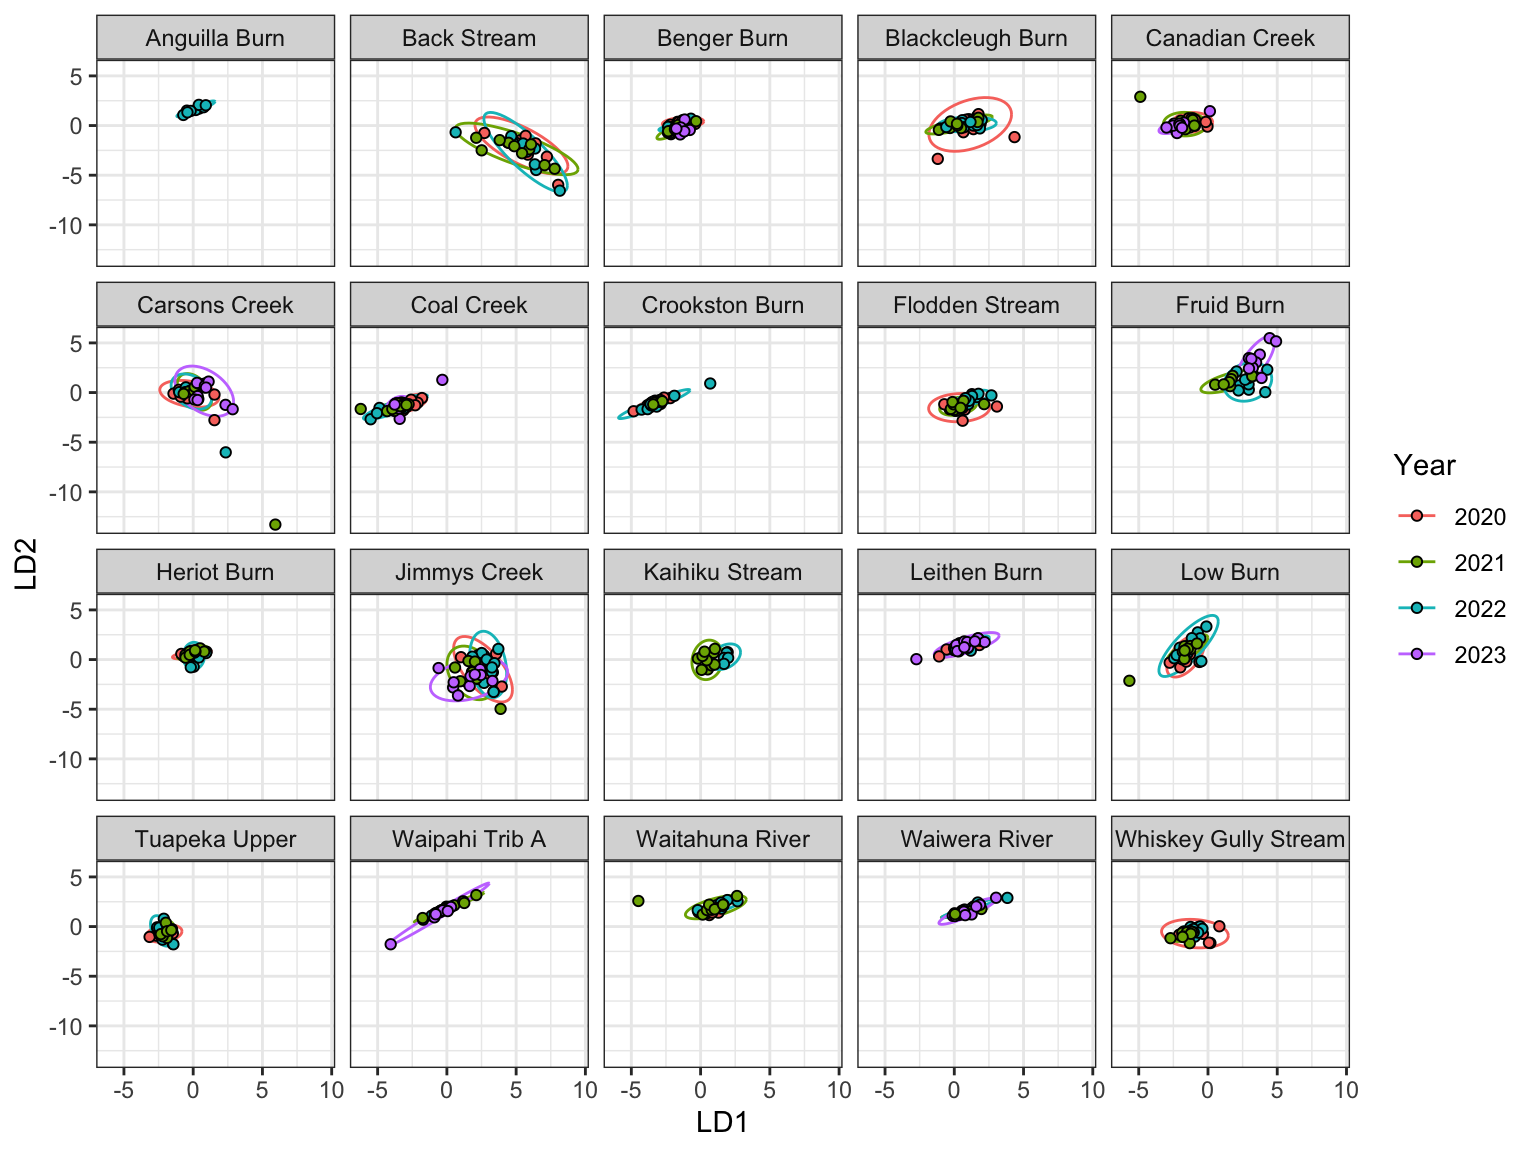

In [ ]:

### Fit to the entire dataset
lda_model <- MASS::lda(Site ~ ., data = df_mean_juv_clean_main)

# In-sample predictions (scores, classes, posteriors)
pred <- predict(lda_model, newdata = df_mean_juv_clean_main)

predicted_labels_J <- pred$class
accuracy_score <- mean(predicted_labels_J == df_mean_juv_clean_main$Site)

posterior_probs_J <- pred$posterior
high_probs_J <- apply(posterior_probs_J, 1, max)

# LDA scores (linear discriminant coordinates)
lda_scores <- pred$x

# Attach IDs and predictors for plotting/export (aligned because we only dropped NAs before)
JdfII <- cbind(
  df_main_full[, c("meanMn55", "meanSr88", "meanBa138"), drop = FALSE],
  Slide_code = df_main_full$Slide_code,
  Year = df_main_full$Year,
  Site = df_main_full$Site,
  predicted_site = predicted_labels_J,
  highest_probs = high_probs_J
)

LD <- cbind(JdfII, LD1 = lda_scores[, 1], LD2 = lda_scores[, 2])

Juv_results <- LD


# Plot
# Scatterplot colored by predicted site
LDA_Plot_all <- ggplot(Juv_results, aes(x = LD1, y = LD2)) +
  geom_point(aes(fill = predicted_site), color = "black", shape = 21) +
  stat_ellipse(aes(col = predicted_site), level = 0.95) +
  theme_bw()

# Scatterplot of LD1 vs LD2, colored by Year, faceted by Site
lda_plot <- ggplot(Juv_results, aes(x = LD1, y = LD2)) +
  stat_ellipse(aes(col = as.factor(Year)), level = 0.95) +
  geom_point(aes(fill = as.factor(Year)), color = "black", shape = 21) +
  labs(x = "LD1", y = "LD2", fill = "Year", color = "Year") +
  facet_wrap(~Site) +
  theme_bw()

ggsave(
  lda_plot,
  file = file.path(out_dir, "fig-lda.png"),
  width = 8,
  height = 6,
  bg = "white",
  dpi = 600
)


# Svirgsden et al. (2018)

## load data

In [ ]:

# load the data from Svirgsden et al. (2018)
Trout_Mehis <- read_excel("data/raw/Trout_NZ_FROM_Mehis.xlsx")

Trib_A_data <- df_mean_juv_clean %>%
  filter(Site == "Waipahi Trib A") %>%
  dplyr::select(Site, Year, meanMn55, meanSr88, meanBa138) %>%
  dplyr::mutate(Year = as.factor(Year), Site = as.factor(Site))

df_mean_juv_main <- df_mean_juv_clean %>%
  dplyr::select(Site, Year, meanMn55, meanSr88, meanBa138) %>%
  dplyr::mutate(Year = as.factor(Year), Site = as.factor(Site))

Trib_A_data_m <- Trout_Mehis %>%
  filter(Site == "Mathisons") %>%
  dplyr::select(Site, Year, meanMn55, meanSr88, meanBa138) %>%
  dplyr::mutate(Year = as.factor(Year), Site = as.factor(Site))

Waipahi_data_M <- Trout_Mehis %>%
  dplyr::select(Site, Year, meanMn55, meanSr88, meanBa138) %>%
  dplyr::mutate(Year = as.factor(Year), Site = as.factor(Site))

# Combine both datasets
Trip_A_full <- rbind(Trib_A_data, Trib_A_data_m)
Trip_A_full$Site[Trip_A_full$Site == "Mathisons"] <- "Waipahi Trib A"
Waipahi_data_full <- rbind(Trib_A_data, Waipahi_data_M)
combined_data_full <- rbind(df_mean_juv_main, Waipahi_data_M)

# Run MANOVA on all response variables
manova_result <- manova(
  cbind(meanMn55, meanSr88, meanBa138) ~ Year,
  data = Trip_A_full
)

# Summarize results
#summary(manova_result)

anova_mn55 <- aov(meanMn55 ~ Year, data = Trip_A_full)
anova_sr88 <- aov(meanSr88 ~ Year, data = Trip_A_full)
anova_ba138 <- aov(meanBa138 ~ Year, data = Trip_A_full)

# Summarize results
#summary(anova_mn55)
#summary(anova_sr88)
#summary(anova_ba138)

tukey_mn55 <- TukeyHSD(anova_mn55)
tukey_sr88 <- TukeyHSD(anova_sr88)
tukey_ba138 <- TukeyHSD(anova_ba138)

# Print results
tukey_mn_df <- as.data.frame(tukey_mn55$Year)
tukey_ba_df <- as.data.frame(tukey_ba138$Year)

# Mn: only one significant comparison
p_mn_2015_2022 <- round(tukey_mn_df["2015-2022", "p adj"], 5)

# Ba: check your actual rownames first, but likely:
p_ba_2015_2022 <- round(tukey_ba_df["2015-2022", "p adj"], 7)
p_ba_2015_2021 <- round(tukey_ba_df["2015-2021", "p adj"], 4)
p_ba_2023_2021 <- round(tukey_ba_df["2023-2021", "p adj"], 4)
p_ba_2023_2022 <- round(tukey_ba_df["2023-2022", "p adj"], 7)


## RF Svirgsden et al. (2018)

In [ ]:

rf_train <- df_mean_juv_main %>%
  select(Site, meanMn55, meanSr88, meanBa138) %>%
  mutate(
    Site = as.factor(Site),
    across(c(meanMn55, meanSr88, meanBa138), as.numeric)
  ) %>%
  drop_na()

# Fixed seed — see note by the first randomForest() call above.
set.seed(42)
rf_model_no_year <- randomForest(
  Site ~ meanMn55 + meanSr88 + meanBa138,
  data = rf_train,
  ntree = 400,
  importance = TRUE
)

print(rf_model_no_year)



Call:
 randomForest(formula = Site ~ meanMn55 + meanSr88 + meanBa138,      data = rf_train, ntree = 400, importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 400
No. of variables tried at each split: 1

        OOB estimate of  error rate: 39.33%
Confusion matrix:
                     Anguilla Burn Back Stream Benger Burn Blackcleugh Burn
Anguilla Burn                    2           0           0                0
Back Stream                      0          25           0                0
Benger Burn                      0           0          25                0
Blackcleugh Burn                 0           1           0               12
Canadian Creek                   0           0           8                0
Carsons Creek                    0           0           2                5
Coal Creek                       1           0           0                0
Crookston Burn                   0           0           1          

[1] 74.35897

## LDA Svirgsden et al. (2018)

In [ ]:

# Perform cross-validation
combined_data_III <- combined_data_full[, c(
  "meanMn55",
  "meanSr88",
  "meanBa138",
  "Site"
)]
num_folds <- nrow(combined_data_III)
accuracy_scores <- rep(0, num_folds)

partition_indices <- rep(1:num_folds, length.out = nrow(combined_data_III))

# Create a matrix to store the classification table for each fold
unique_classes <- unique(combined_data_III$Site)
class_table <- matrix(
  0,
  nrow = length(unique_classes),
  ncol = length(unique_classes)
)

# Set row and column names for the class_table
rownames(class_table) <- colnames(class_table) <- unique_classes

for (i in 1:num_folds) {
  training_data <- combined_data_III[partition_indices != i, ]
  testing_data <- combined_data_III[partition_indices == i, ]

  lda_model <- lda(Site ~ ., data = training_data)

  predictions <- predict(lda_model, testing_data)
  predicted_labels <- predictions$class

  accuracy_scores[i] <- sum(predicted_labels == testing_data$Site) /
    nrow(testing_data)

  # Update the classification table with the predicted and actual labels
  current_table <- table(predicted_labels, testing_data$Site)
  class_table[rownames(current_table), colnames(current_table)] <- class_table[
    rownames(current_table),
    colnames(current_table)
  ] +
    current_table
}

class_table


                     Benger Burn Blackcleugh Burn Carsons Creek Back Stream
Benger Burn                   34                0             4           0
Blackcleugh Burn               0               11             2           0
Carsons Creek                  0                4             6           1
Back Stream                    0                1             2          25
Crookston Burn                 0                0             0           0
Leithen Burn                   0                1             2           0
Flodden Stream                 0                0             1           0
Heriot Burn                    3                7            11           0
Whiskey Gully Stream           0                2             3           0
Waitahuna River                0                0             1           0
Tuapeka Upper                  0                1             0           0
Low Burn                       0                0             0           0
Coal Creek  

[1] 49.84227

## Comparison summary

In [ ]:

svirgsden_comparison <- data.frame(
  Comparison = c(
    "Mn: 2015 vs 2022",
    "Ba: 2022 vs 2015",
    "Ba: 2021 vs 2015",
    "Ba: 2023 vs 2021",
    "Ba: 2023 vs 2022",
    "RF model accuracy (2015 samples → Waipahi Trib A)",
    "LDA model accuracy (2015 samples → Waipahi Trib A)"
  ),
  Value = c(
    paste0("p = ", format(p_mn_2015_2022, scientific = FALSE)),
    paste0("p = ", format(p_ba_2015_2022, scientific = FALSE)),
    paste0("p = ", format(p_ba_2015_2021, scientific = FALSE)),
    paste0("p = ", format(p_ba_2023_2021, scientific = FALSE)),
    paste0("p = ", format(p_ba_2023_2022, scientific = FALSE)),
    paste0(round(accuracy_Svirgsden_rf, 1), "%"),
    paste0(round(accuracy_Svirgsden_lda, 1), "%")
  )
)

write.csv(
  svirgsden_comparison,
  file = file.path(out_dir, "svirgsden_comparison_table.csv"),
  row.names = FALSE
)

knitr::kable(svirgsden_comparison)


  Comparison                                           Value
  ---------------------------------------------------- ---------------
  Mn: 2015 vs 2022                                     p = 0.00783
  Ba: 2022 vs 2015                                     p = 0.0000354
  Ba: 2021 vs 2015                                     p = 0.0114
  Ba: 2023 vs 2021                                     p = 0.0117
  Ba: 2023 vs 2022                                     p = 0.0000894
  RF model accuracy (2015 samples → Waipahi Trib A)    74.4%
  LDA model accuracy (2015 samples → Waipahi Trib A)   49.8%


# NNCA

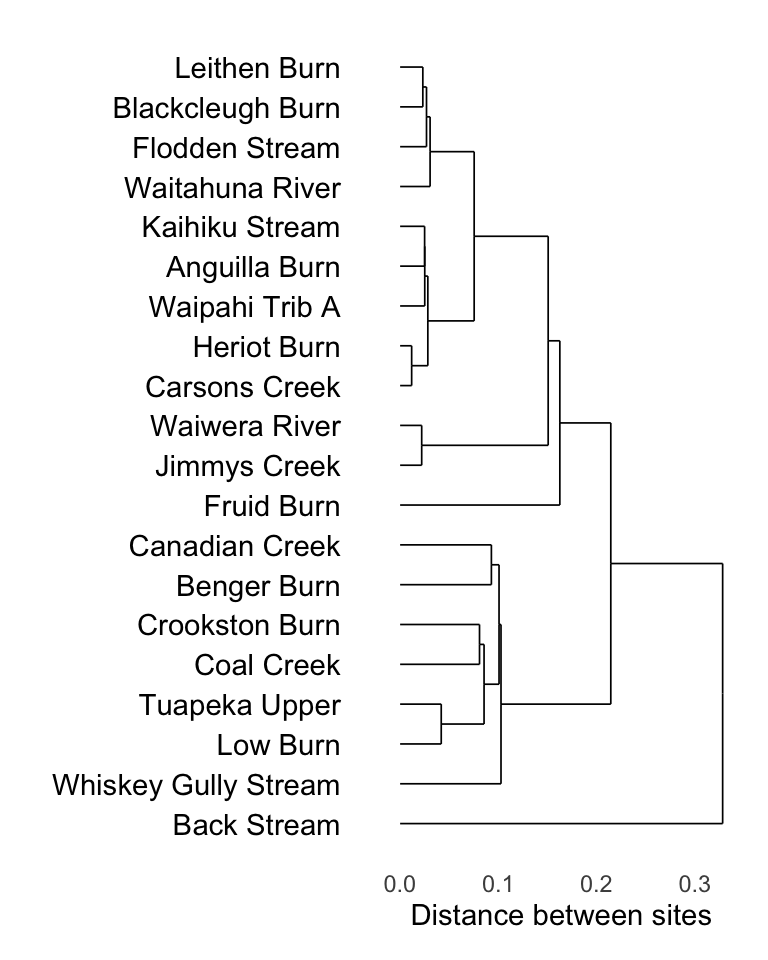

In [ ]:

# Calculate mean elemental composition per site
mean_by_group <- aggregate(
  cbind(meanMn55, meanSr88, meanBa138) ~ Site,
  data = Juv_results,
  FUN = mean
)

# 1) Prepare matrix with Site names as row names (no reordering)
#    Assumes mean_by_group has first column 'Site' and remaining numeric features
data_mat <- as.matrix(mean_by_group[, -1, drop = FALSE])
rownames(data_mat) <- mean_by_group$Site

# 2) Distance + clustering (same as before)
distance_matrix <- dist(data_mat)
fit <- hclust(distance_matrix, method = "single")

# 3) Determine optimal cluster count via silhouette (same logic)
k_max <- max(2, min(19, nrow(mean_by_group) - 1))
sil_scores <- sapply(2:k_max, function(k) {
  grp <- cutree(fit, k = k)
  mean(silhouette(grp, distance_matrix)[, "sil_width"])
})
optimal_clusters <- which.max(sil_scores) + 1

# 4) Convert to ggdendro data; labels come directly from hclust (Site names via rownames)
dd <- ggdendro::dendro_data(fit, type = "rectangle")

# 5) Right panel: horizontal dendrogram (suppress leaf labels here to avoid duplication)
dend_plot <- ggplot() +
  geom_segment(
    data = dd$segments,
    aes(x = y, y = x, xend = yend, yend = xend),
    linewidth = 0.3
  ) +
  labs(x = "Distance between sites", y = NULL) +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.text.y = element_blank(),
    axis.ticks.y = element_blank(),
    plot.title.position = "plot"
  )

# 6) Left panel: Site labels in dendrogram leaf order (already Site names)
labels_df <- dd$labels
labels_df$y <- labels_df$x
left_labels <- ggplot(labels_df, aes(x = 1, y = y, label = label)) +
  geom_text(hjust = 1) +
  xlim(0.5, 1.02) +
  labs(x = NULL, y = NULL) +
  theme_void()

# 7) Combine panels: LEFT labels (narrow) + RIGHT tree (wide)
NNCA_tree_plot <- left_labels +
  dend_plot +
  patchwork::plot_layout(widths = c(1, 1))

ggsave(
  NNCA_tree_plot,
  file = file.path(out_dir, " fig-nnca.png"),
  width = 4,
  height = 5,
  dpi = 600
)

NNCA_tree_plot


# Preform RF and LDA over the NNCA groups

In [ ]:

# Assign cluster numbers to each Catch_location
mean_by_group$NNCA <- cutree(fit, k = optimal_clusters)

# Merge NNCA data into Juv_results based on Catch_location
Juv_results_NNCA <- Juv_results %>%
  dplyr::left_join(mean_by_group %>% dplyr::select(Site, NNCA), by = "Site")

# Select useful columns
Juv_NNCA <- Juv_results_NNCA %>%
  dplyr::select(meanMn55, meanSr88, meanBa138, NNCA) %>%
  dplyr::mutate(NNCA = as.factor(NNCA))

cluster_levels <- levels(Juv_NNCA$NNCA)
K <- length(cluster_levels)

### RF
# Fixed seed — see note by the first randomForest() call above.
set.seed(42)
rf_model_nnca <- randomForest(
  NNCA ~ .,
  data = Juv_NNCA,
  ntree = 400,
  importance = TRUE
)

conf_rf <- rf_model_nnca$confusion[, cluster_levels] # drop class.error
accuracy_rf_nnca <- sum(diag(conf_rf)) / sum(conf_rf)
accuracy_rf_nnca <- accuracy_rf_nnca * 100

### LDA - LOOCV confusion matrix
num_folds <- nrow(Juv_NNCA)
accuracy_scores_lda <- numeric(num_folds)

lda_class_table <- matrix(
  0,
  nrow = K,
  ncol = K,
  dimnames = list(Predicted = cluster_levels, Actual = cluster_levels)
)

for (i in seq_len(num_folds)) {
  training_data <- Juv_NNCA[-i, ]
  testing_data <- Juv_NNCA[i, , drop = FALSE]

  lda_model_cv <- MASS::lda(NNCA ~ ., data = training_data)
  pred_cv <- predict(lda_model_cv, newdata = testing_data)$class

  accuracy_scores_lda[i] <- mean(pred_cv == testing_data$NNCA)

  tbl_i <- table(
    factor(pred_cv, levels = cluster_levels),
    factor(testing_data$NNCA, levels = cluster_levels)
  )
  lda_class_table <- lda_class_table + tbl_i
}

mean_accuracy_lda <- mean(accuracy_scores_lda)
accuracy_lda_nnca <- sum(diag(lda_class_table)) / sum(lda_class_table)
accuracy_lda_nnca <- accuracy_lda_nnca * 100
# Final LDA for LD scores (plot use)
lda_model_final <- MASS::lda(NNCA ~ ., data = Juv_NNCA)
predicted_labels <- predict(lda_model_final, newdata = Juv_NNCA)$class
LD <- predict(lda_model_final)$x

Juv_NNCA2 <- cbind(
  Juv_NNCA,
  predicted_labels = predicted_labels,
  LD1 = LD[, 1],
  LD2 = LD[, 2]
) %>%
  dplyr::mutate(Correct = ifelse(NNCA == predicted_labels, "1", "0"))

# ---- Build side-by-side table ----

conf_rf_wide <- as.data.frame.matrix(conf_rf[, cluster_levels])
conf_lda_wide <- as.data.frame.matrix(lda_class_table)

combined <- cbind(conf_rf_wide, conf_lda_wide)

# Move rownames to explicit column
combined_display <- data.frame(
  Predicted = cluster_levels,
  combined,
  check.names = FALSE
)

# Rename to avoid duplicates
colnames(combined_display) <- c(
  "Predicted",
  paste0("RF_", cluster_levels),
  paste0("LDA_", cluster_levels)
)

write.csv(
  combined_display,
  file = file.path(out_dir, "combined_nnca_conf_matrix.csv"),
  row.names = TRUE
)


knitr::kable(combined_display)


  Predicted     RF_1   RF_2   RF_3   LDA_1   LDA_2   LDA_3
  ----------- ------ ------ ------ ------- ------- -------
  1              322      2     14     317       4      21
  2                5     25      0       8      26       0
  3               18      0    209      13       0     206


### NNCA-LDA plot

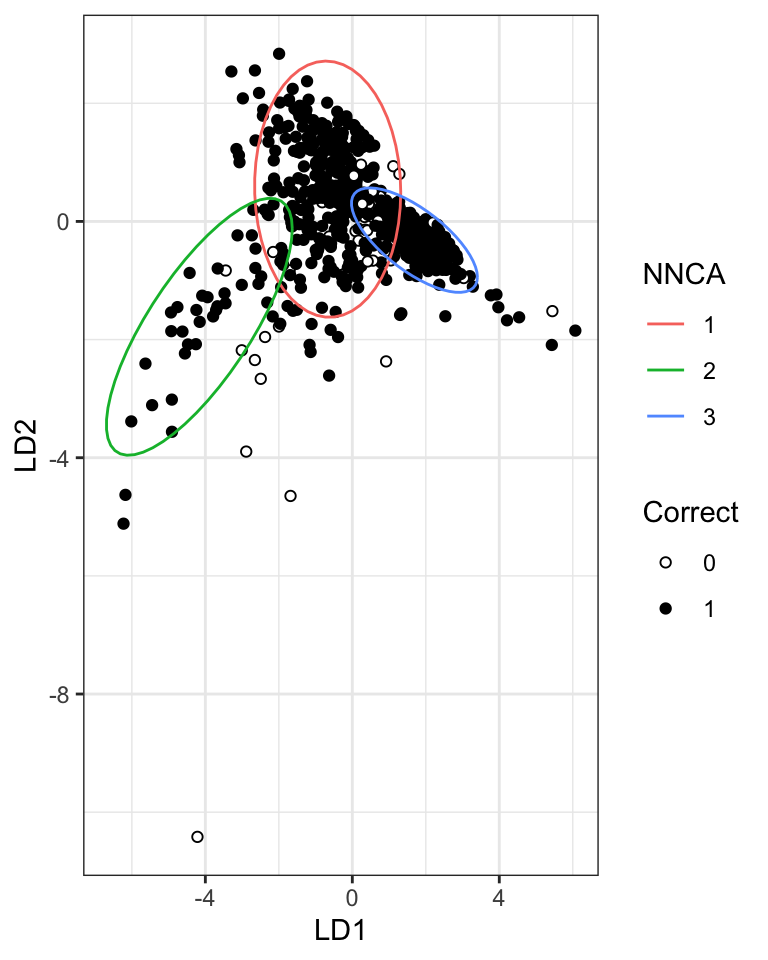

In [ ]:

# Create a column to indicate correctness of prediction
Juv_NNCA2$Correct <- ifelse(
  Juv_NNCA2$NNCA == Juv_NNCA2$predicted_labels,
  "1",
  "0"
)

# Plot with correctly classified in black, misclassified in white
LDA_NNCA <- ggplot(Juv_NNCA2, aes(x = LD1, y = LD2)) +
  geom_point(aes(fill = Correct), color = 'black', shape = 21) +
  scale_fill_manual(values = c("1" = "black", "0" = "white")) +
  stat_ellipse(aes(col = NNCA), level = 0.95) +
  theme_bw()

ggsave(
  LDA_NNCA,
  file = file.path(out_dir, "fig-nnca-lda.png"),
  width = 5,
  height = 4,
  bg = "white",
  dpi = 600
)

LDA_NNCA


# Tempotal variation

In [ ]:

sites <- list(
  "Waiwera River" = filter(df_mean_juv_clean, Site == "Waiwera River"),
  "Waitahuna River" = filter(df_mean_juv_clean, Site == "Waitahuna River"),
  "Fruid Burn" = filter(df_mean_juv_clean, Site == "Fruid Burn")
)

elements <- c("meanMn55", "meanSr88", "meanBa138")

results <- list()

for (site_name in names(sites)) {
  df_site <- sites[[site_name]]
  df_site$Year <- as.factor(df_site$Year)

  for (elem in elements) {
    formula <- as.formula(paste(elem, "~ Year"))
    anova_res <- aov(formula, data = df_site)
    sm <- summary(anova_res)
    f_val <- round(sm[[1]]$`F value`[1], 3)
    p_val <- sm[[1]]$`Pr(>F)`[1]

    # Significance stars
    sig <- dplyr::case_when(
      p_val < 0.001 ~ "***",
      p_val < 0.01 ~ "**",
      p_val < 0.05 ~ "*",
      TRUE ~ ""
    )

    # Always return a character string
    p_fmt <- as.character(
      ifelse(
        p_val < 0.0001,
        formatC(p_val, format = "e", digits = 2),
        as.character(round(p_val, 3))
      )
    )

    # Tukey HSD
    tukey <- TukeyHSD(anova_res)
    tukey_df <- as.data.frame(tukey$Year)
    tukey_df$comparison <- rownames(tukey_df)

    tukey_str <- if (p_val < 0.05) {
      paste(
        apply(tukey_df, 1, function(row) {
          comp <- row["comparison"]
          diff <- round(as.numeric(row["diff"]), 5)
          p_t <- round(as.numeric(row["p adj"]), 4)
          paste0(comp, ": ", diff, " (p=", p_t, ")")
        }),
        collapse = "\n"
      )
    } else {
      ""
    }

    results[[length(results) + 1]] <- data.frame(
      Site = site_name,
      Element = elem,
      F_value = f_val,
      Pr_F = p_fmt,
      Significance = sig,
      Tukey_HSD = tukey_str,
      stringsAsFactors = FALSE
    )
  }
}


tbl_temporal <- bind_rows(results)

# Keep site name only on first row per site
tbl_temporal <- tbl_temporal |>
  group_by(Site) |>
  mutate(Site = ifelse(row_number() == 1, Site, "")) |>
  ungroup()

colnames(tbl_temporal) <- c(
  "Site",
  "Element",
  "F value",
  "Pr(>F)",
  "Significance",
  "Tukey HSD Results"
)

knitr::kable(tbl_temporal)

# Re-run the ANOVAs for Waiwera specifically
waiwera_data <- filter(df_mean_juv_clean, Site == "Waiwera River") |>
  mutate(Year = as.factor(Year))

fruid_data <- filter(df_mean_juv_clean, Site == "Fruid Burn") |>
  mutate(Year = as.factor(Year))

tukey_waiwera_mn <- TukeyHSD(aov(meanMn55 ~ Year, data = waiwera_data))

tukey_fruid_mn <- TukeyHSD(aov(meanMn55 ~ Year, data = fruid_data))
tukey_fruid_sr <- TukeyHSD(aov(meanSr88 ~ Year, data = fruid_data))
tukey_fruid_ba <- TukeyHSD(aov(meanBa138 ~ Year, data = fruid_data))

# Extract p-values
p_waiwera_mn_2022_2021 <- round(
  as.data.frame(tukey_waiwera_mn$Year)["2022-2021", "p adj"],
  4
)
p_waiwera_mn_2023_2022 <- round(
  as.data.frame(tukey_waiwera_mn$Year)["2023-2022", "p adj"],
  4
)
p_waiwera_mn_2023_2021 <- round(
  as.data.frame(tukey_waiwera_mn$Year)["2023-2021", "p adj"],
  4
)

p_fruid_mn_2022_2021 <- round(
  as.data.frame(tukey_fruid_mn$Year)["2022-2021", "p adj"],
  4
)
p_fruid_mn_2023_2022 <- round(
  as.data.frame(tukey_fruid_mn$Year)["2023-2022", "p adj"],
  4
)
p_fruid_mn_2023_2021 <- round(
  as.data.frame(tukey_fruid_mn$Year)["2023-2021", "p adj"],
  4
)

p_fruid_sr_2022_2021 <- round(
  as.data.frame(tukey_fruid_sr$Year)["2022-2021", "p adj"],
  4
)
p_fruid_sr_2023_2022 <- round(
  as.data.frame(tukey_fruid_sr$Year)["2023-2022", "p adj"],
  4
)
p_fruid_sr_2023_2021 <- round(
  as.data.frame(tukey_fruid_sr$Year)["2023-2021", "p adj"],
  4
)

p_fruid_ba_2022_2021 <- round(
  as.data.frame(tukey_fruid_ba$Year)["2022-2021", "p adj"],
  4
)
p_fruid_ba_2023_2022 <- round(
  as.data.frame(tukey_fruid_ba$Year)["2023-2022", "p adj"],
  4
)
p_fruid_ba_2023_2021 <- round(
  as.data.frame(tukey_fruid_ba$Year)["2023-2021", "p adj"],
  4
)


saveRDS(
  list(
    accuracy_lda = accuracy_lda,
    accuracy_rf = accuracy_rf,
    p_waiwera_mn_2022_2021 = p_waiwera_mn_2022_2021,
    p_mn_2015_2022 = p_mn_2015_2022,
    p_ba_2015_2022 = p_ba_2015_2022,
    p_ba_2015_2021 = p_ba_2015_2021,
    p_ba_2023_2021 = p_ba_2023_2021,
    p_ba_2023_2022 = p_ba_2023_2022,
    accuracy_Svirgsden_rf = accuracy_Svirgsden_rf,
    accuracy_Svirgsden_lda = accuracy_Svirgsden_lda,
    accuracy_lda_nnca = accuracy_lda_nnca,
    accuracy_rf_nnca = accuracy_rf_nnca
  ),
  "data/derived/inline_values.rds"
)


  -------------------------------------------------------------------------------------------------
  Site      Element    F value Pr(\>F)   Significance   Tukey HSD Results
  --------- ---------- ------- --------- -------------- -------------------------------------------
  Waiwera   meanMn55     7.745 0.002     \*\*           2022-2021: -0.00474 (p=0.0036)
  River                                                 

  -------------------------------------------------------------------------------------------------


```` markdown
---
title: "Analysis Notebook"
format:
  html:
    fig-path: "analysis_files/figure-html/"
    theme:
      light: flatly
      dark: darkly
    code-fold: true
    code-tools: true
    code-summary: "View Code"
    toc: true
    toc-depth: 3
    number-sections: true
fig-width: 8
fig-height: 8

execute:
  freeze: auto
  cache: false

---

# Setup
quarto-executable-code-5450563D

```r
#| label: setup
#| include: true

packages <- c(
  "here",
  "gt",
  "knitr",
  "DT",
  "palmerpenguins",
  "caret",
  "cluster",
  "MASS",
  "ggpubr",
  "randomForest",
  "patchwork",
  "tidyverse",
  "dplyr",
  "ggplot2",
  "readxl",
  "writexl",
  "readr"
)

quiet_load <- function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    suppressWarnings(suppressMessages(install.packages(
      pkg,
      dependencies = TRUE
    )))
  }
  suppressPackageStartupMessages(require(
    pkg,
    character.only = TRUE,
    quietly = TRUE
  ))
  invisible(TRUE)
}

invisible(lapply(packages, quiet_load))

base_dir <- here::here()
data_dir <- file.path(base_dir, "data")
raw_data_dir <- file.path(data_dir, "raw")
der_data_dir <- file.path(data_dir, "derived")
out_dir <- file.path(base_dir, "outputs")
txt_file_dir <- file.path(base_dir, "data/raw/JUV_data")

# Set base for plots
base_theme_bw <- theme_classic() +
  theme(
    text = element_text(family = "Arial", size = 11),
    axis.title = element_text(face = "plain"),
    axis.text = element_text(face = "plain"),
    plot.title = element_text(face = "plain"),
    strip.text = element_text(face = "plain"),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.3)
  )
theme_set(base_theme_bw)

Slidecode_juv <- read_excel("data/raw/Slidecode_site_juv.xlsx")

# S1H15, S2B4, 2SF9, S3B12, S3D5, S4D1 missing from raw data files
```

# Data import (run only if df_ablation_juv & df_mean_juv not exist yet)
quarto-executable-code-5450563D

```r
#| label: Data import (run only if df_ablation_juv & df_mean_juv not exist yet)
#| include: false

# Standard atomic weight
aw <- list(
  Li7 = 6.941,
  Na23 = 22.989769,
  Mg24 = 24.305,
  Al27 = 26.9815386,
  P31 = 30.9738,
  K39 = 39.0983,
  Ca43 = 40.078,
  Mn55 = 54.938045,
  Fe57 = 55.845,
  Cu65 = 63.546,
  Zn66 = 65.39,
  Rb85 = 85.4678,
  Sr88 = 87.62,
  Ba138 = 137.327
)

# Rows to use for mean/SEM calculations
n_rows <- 197

# list all the text files in the folder
#### MAKE SURE THE FILES ARE .txt
file_names <- list.files(
  path = txt_file_dir,
  pattern = "\\.txt$",
  ignore.case = TRUE
)

# Create empty data frames to store results
df_raw_ablation_juv <- data.frame()
df_raw_mean_juv <- data.frame()

# Loop through each file and read it into a data frame
for (file_name in file_names) {
  # Construct the file path
  file_path <- file.path(txt_file_dir, file_name)

  # Read the file into a data frame
  slide <- utils::read.delim(file_path)

  # Remove rows with NAs
  slide <- stats::na.omit(slide)

  # Compute Slide_code (file name without extension)
  slide_code <- tools::file_path_sans_ext(basename(file_name))

  # Make new column with and convert from g/g to mmol/molCa results
  slide$`Li7_mmol_molCa` <- 100100 * slide$Li_g_g_m7 / aw$Li7
  slide$`Na23_mmol_molCa` <- 100100 * slide$Na_g_g_m23 / aw$Na23
  slide$`Mg24_mmol_molCa` <- 100100 * slide$Mg_g_g_m24 / aw$Mg24
  slide$`Al27_mmol_molCa` <- 100100 * slide$Al_g_g_m27 / aw$Al27
  slide$`P31_mmol_molCa` <- 100100 * slide$P_g_g_m31 / aw$P31
  slide$`K39_mmol_molCa` <- 100100 * slide$K_g_g_m39 / aw$K39
  slide$`Mn55_mmol_molCa` <- 100100 * slide$Mn_g_g_m55 / aw$Mn55
  slide$`Fe57_mmol_molCa` <- 100100 * slide$Fe_g_g_m57 / aw$Fe57
  slide$`Cu65_mmol_molCa` <- 100100 * slide$Cu_g_g_m65 / aw$Cu65
  slide$`Zn66_mmol_molCa` <- 100100 * slide$Zn_g_g_m66 / aw$Zn66
  slide$`Rb85_mmol_molCa` <- 100100 * slide$Rb_g_g_m85 / aw$Rb85
  slide$`Sr88_mmol_molCa` <- 100100 * slide$Sr_g_g_m88 / aw$Sr88
  slide$`Ba138_mmol_molCa` <- 100100 * slide$Ba_g_g_m138 / aw$Ba138

  # Add columns for the file name and code
  slide$File <- file_name
  slide$Slide_code <- slide_code

  # Calculate means of mmol/molCa results
  meanLi7 <- mean(slide[1:n_rows, "Li7_mmol_molCa"], na.rm = TRUE)
  meanNa23 <- mean(slide[1:n_rows, "Na23_mmol_molCa"], na.rm = TRUE)
  meanMg24 <- mean(slide[1:n_rows, "Mg24_mmol_molCa"], na.rm = TRUE)
  meanAl27 <- mean(slide[1:n_rows, "Al27_mmol_molCa"], na.rm = TRUE)
  meanP31 <- mean(slide[1:n_rows, "P31_mmol_molCa"], na.rm = TRUE)
  meanK39 <- mean(slide[1:n_rows, "K39_mmol_molCa"], na.rm = TRUE)
  meanMn55 <- mean(slide[1:n_rows, "Mn55_mmol_molCa"], na.rm = TRUE)
  meanFe57 <- mean(slide[1:n_rows, "Fe57_mmol_molCa"], na.rm = TRUE)
  meanCu65 <- mean(slide[1:n_rows, "Cu65_mmol_molCa"], na.rm = TRUE)
  meanZn66 <- mean(slide[1:n_rows, "Zn66_mmol_molCa"], na.rm = TRUE)
  meanRb85 <- mean(slide[1:n_rows, "Rb85_mmol_molCa"], na.rm = TRUE)
  meanSr88 <- mean(slide[1:n_rows, "Sr88_mmol_molCa"], na.rm = TRUE)
  meanBa138 <- mean(slide[1:n_rows, "Ba138_mmol_molCa"], na.rm = TRUE)

  # Calculate standard error of the mean (SEM)
  semLi7 <- stats::sd(slide[1:n_rows, "Li7_mmol_molCa"], na.rm = TRUE) /
    sqrt(n_rows)
  semNa23 <- stats::sd(slide[1:n_rows, "Na23_mmol_molCa"], na.rm = TRUE) /
    sqrt(n_rows)
  semMg24 <- stats::sd(slide[1:n_rows, "Mg24_mmol_molCa"], na.rm = TRUE) /
    sqrt(n_rows)
  semAl27 <- stats::sd(slide[1:n_rows, "Al27_mmol_molCa"], na.rm = TRUE) /
    sqrt(n_rows)
  semP31 <- stats::sd(slide[1:n_rows, "P31_mmol_molCa"], na.rm = TRUE) /
    sqrt(n_rows)
  semK39 <- stats::sd(slide[1:n_rows, "K39_mmol_molCa"], na.rm = TRUE) /
    sqrt(n_rows)
  semMn55 <- stats::sd(slide[1:n_rows, "Mn55_mmol_molCa"], na.rm = TRUE) /
    sqrt(n_rows)
  semFe57 <- stats::sd(slide[1:n_rows, "Fe57_mmol_molCa"], na.rm = TRUE) /
    sqrt(n_rows)
  semCu65 <- stats::sd(slide[1:n_rows, "Cu65_mmol_molCa"], na.rm = TRUE) /
    sqrt(n_rows)
  semZn66 <- stats::sd(slide[1:n_rows, "Zn66_mmol_molCa"], na.rm = TRUE) /
    sqrt(n_rows)
  semRb85 <- stats::sd(slide[1:n_rows, "Rb85_mmol_molCa"], na.rm = TRUE) /
    sqrt(n_rows)
  semSr88 <- stats::sd(slide[1:n_rows, "Sr88_mmol_molCa"], na.rm = TRUE) /
    sqrt(n_rows)
  semBa138 <- stats::sd(slide[1:n_rows, "Ba138_mmol_molCa"], na.rm = TRUE) /
    sqrt(n_rows)

  # Add the data frame to the cumulative raw results
  df_raw_ablation_juv <- rbind(df_raw_ablation_juv, slide)

  # Create a data frame with means and SEM for this file and append
  df_raw_mean_juv <- rbind(
    df_raw_mean_juv,
    data.frame(
      file_name = file_name,
      Slide_code = slide_code,
      meanLi7 = meanLi7,
      semLi7 = semLi7,
      meanNa23 = meanNa23,
      semNa23 = semNa23,
      meanMg24 = meanMg24,
      semMg24 = semMg24,
      meanAl27 = meanAl27,
      semAl27 = semAl27,
      meanP31 = meanP31,
      semP31 = semP31,
      meanK39 = meanK39,
      semK39 = semK39,
      meanMn55 = meanMn55,
      semMn55 = semMn55,
      meanFe57 = meanFe57,
      semFe57 = semFe57,
      meanCu65 = meanCu65,
      semCu65 = semCu65,
      meanZn66 = meanZn66,
      semZn66 = semZn66,
      meanRb85 = meanRb85,
      semRb85 = semRb85,
      meanSr88 = meanSr88,
      semSr88 = semSr88,
      meanBa138 = meanBa138,
      semBa138 = semBa138,
      stringsAsFactors = FALSE
    )
  )
}

# comebine the slide info with the df's
df_raw_ablation_juv <- df_raw_ablation_juv %>%
  mutate(Slide_code = as.character(Slide_code))
df_raw_mean_juv <- df_raw_mean_juv %>%
  mutate(Slide_code = as.character(Slide_code))
Slidecode_juv <- Slidecode_juv %>% mutate(Slide_code = as.character(Slide_code))

df_ablation_juv <- df_raw_ablation_juv %>%
  left_join(Slidecode_juv, by = "Slide_code")

df_mean_juv <- df_raw_mean_juv %>%
  left_join(Slidecode_juv, by = "Slide_code")

# filter out ablations with valerite and unstable Ca43_CPS
df_ablation_juv <- df_ablation_juv %>%
  dplyr::filter(
    !Slide_code %in% c("S3F12", "S1F2", "S3D9", "S2C11", "S3G9", "S4E3")
  ) #valerite "S2C11", "S3G9", "S4E3"

df_mean_juv <- df_mean_juv %>%
  dplyr::filter(
    !Slide_code %in% c("S3F12", "S1F2", "S3D9", "S2C11", "S3G9", "S4E3")
  ) #valerite "S2C11", "S3G9", "S4E3"

# save the df's
write.csv(
  df_ablation_juv,
  file = file.path(der_data_dir, "df_ablation_juv.csv"),
  row.names = FALSE
)
write.csv(
  df_mean_juv,
  file = file.path(der_data_dir, "df_mean_juv.csv"),
  row.names = FALSE
)
```


# Plot the raw ablations
quarto-executable-code-5450563D

```r
#| label: fig-raw-ablations
#| include: true
#| fig-width: 12
#| fig-height: 10
#| fig-cap: "The raw ablations of all the otoliths for each of the 13 elements"

df_ablation_juv <- read_csv("data/derived/df_ablation_juv.csv")
df_mean_juv <- read_csv("data/derived/df_mean_juv.csv")

# Define the desired element order (used for pivoting and facet order)
elems <- c(
  "Li7_mmol_molCa",
  "Na23_mmol_molCa",
  "Mg24_mmol_molCa",
  "Al27_mmol_molCa",
  "P31_mmol_molCa",
  "K39_mmol_molCa",
  "Mn55_mmol_molCa",
  "Fe57_mmol_molCa",
  "Cu65_mmol_molCa",
  "Zn66_mmol_molCa",
  "Rb85_mmol_molCa",
  "Sr88_mmol_molCa",
  "Ba138_mmol_molCa"
)

# convert to long format
df_ablation_juv_long <- df_ablation_juv %>%
  tidyr::pivot_longer(
    cols = dplyr::all_of(elems),
    names_to = "Element",
    values_to = "Concentration"
  ) %>%
  dplyr::mutate(Element = factor(Element, levels = elems))

# Plot with facets
raw_ablation_plot <- ggplot(
  df_ablation_juv_long,
  aes(
    x = ElapsedTime_s,
    y = Concentration,
    color = Slide_code,
    group = Slide_code
  )
) +
  geom_line() +
  facet_wrap(~Element, scales = "free_y") +
  theme_bw() +
  theme(legend.position = "none") +
  labs(y = "Concentration (mmol/molCa)", x = "Elapsed Time (s)") +
  scale_color_discrete(name = "Slide_code")

ggsave(
  raw_ablation_plot,
  file = file.path(out_dir, "fig-raw-ablations.png"),
  width = 12,
  height = 10,
  dpi = 600
)

```


# Element selection
quarto-executable-code-5450563D

```r
#| label: tbl-element-selection
#| include: true
#| tbl-cap: "Output of MANOVA’s testing the mean of the thirteen trace elements between sites and year separately. The green colour indicating spatial variable but temporal stable."

# Set vars
vars <- c(
  "meanLi7",
  "meanNa23",
  "meanMg24",
  "meanAl27",
  "meanP31",
  "meanK39",
  "meanMn55",
  "meanFe57",
  "meanCu65",
  "meanZn66",
  "meanRb85",
  "meanSr88",
  "meanBa138"
)

df_mean_juv_clean <- df_mean_juv %>%
  select(Slide_code, Year, Site, all_of(vars)) %>%
  mutate(across(c(Slide_code, Year, Site), as.factor))

element_data <- select(df_mean_juv_clean, all_of(vars))

# MANOVA for Year
manova_year <- manova(as.matrix(element_data) ~ Year, data = df_mean_juv_clean)

# MANOVA for Site
manova_site <- manova(as.matrix(element_data) ~ Site, data = df_mean_juv_clean)

# ANOVA for each element
anova_row <- function(v, f) {
  a <- anova(aov(reformulate(f, v), df_mean_juv_clean))
  if (f %in% rownames(a)) {
    tibble(
      Variables = v,
      Factor = f,
      Df = a[f, "Df"],
      `Sum Sq` = a[f, "Sum Sq"],
      `Mean Sq` = a[f, "Mean Sq"],
      `F value` = a[f, "F value"],
      p_value = a[f, "Pr(>F)"]
    )
  } else {
    tibble(
      Variables = v,
      Factor = f,
      Df = NA_integer_,
      `Sum Sq` = NA_real_,
      `Mean Sq` = NA_real_,
      `F value` = NA_real_,
      p_value = NA_real_
    )
  }
}

anova_table <- crossing(Variables = vars, Factor = c("Year", "Site")) %>%
  pmap_dfr(~ anova_row(..1, ..2)) %>%
  mutate(
    Variables = factor(Variables, levels = vars),
    Factor = factor(Factor, levels = c("Year", "Site"))
  ) %>%
  arrange(Variables, Factor)

element_selection_table <- anova_table %>%
  select(Variables, Factor, p_value, `F value`) %>%
  pivot_wider(
    names_from = Factor,
    values_from = c(p_value, `F value`),
    names_sep = "_"
  ) %>%
  mutate(
    p_site_adj = p.adjust(p_value_Site, "BH"),
    p_year_adj = p.adjust(p_value_Year, "BH"),
    spatially_variable = p_site_adj < 0.05,
    temporally_stable = p_year_adj >= 0.05,
    classification = case_when(
      spatially_variable &
        temporally_stable ~ "Spatially variable & temporally stable",
      spatially_variable ~ "Spatially variable, NOT temporally stable",
      temporally_stable ~ "Temporally stable, NOT spatially variable",
      TRUE ~ "No clear effect"
    )
  )

# Prepare display table with nice element names
element_selection_display <- element_selection_table %>%
  mutate(
    Element = case_when(
      Variables == "meanLi7" ~ "Li⁷",
      Variables == "meanNa23" ~ "Na²³",
      Variables == "meanMg24" ~ "Mg²⁴",
      Variables == "meanAl27" ~ "Al²⁷",
      Variables == "meanP31" ~ "P³¹",
      Variables == "meanK39" ~ "K³⁹",
      Variables == "meanMn55" ~ "Mn⁵⁵",
      Variables == "meanFe57" ~ "Fe⁵⁷",
      Variables == "meanCu65" ~ "Cu⁶⁵",
      Variables == "meanZn66" ~ "Zn⁶⁶",
      Variables == "meanRb85" ~ "Rb⁸⁵",
      Variables == "meanSr88" ~ "Sr⁸⁸",
      Variables == "meanBa138" ~ "Ba¹³⁸",
      TRUE ~ as.character(Variables)
    )
  ) %>%
  select(
    Element,
    `F-value (Site)` = `F value_Site`,
    `p-value (Site)` = p_site_adj,
    `F-value (Year)` = `F value_Year`,
    `p-value (Year)` = p_year_adj,
    `Spatial Variability` = spatially_variable,
    `Temporal Stability` = temporally_stable,
    Classification = classification
  )

# Save CSV (without fancy element names for easier processing)
write.csv(
  element_selection_table %>%
    mutate(Element = gsub("mean", "", Variables)) %>%
    select(
      Element,
      `F value_Site`,
      p_site_adj,
      `F value_Year`,
      p_year_adj,
      classification
    ),
  file = file.path(out_dir, "element_selection_table.csv"),
  row.names = FALSE
)

# Create interactive table with color coding
datatable(
  element_selection_display,
  options = list(
    pageLength = 13,
    scrollX = TRUE,
    dom = 't', # Hide search box and pagination for this small table
    columnDefs = list(
      list(className = 'dt-center', targets = 1:7)
    )
  ),
  rownames = FALSE
) %>%
  formatRound(columns = c('F-value (Site)', 'F-value (Year)'), digits = 2) %>%
  formatSignif(columns = c('p-value (Site)', 'p-value (Year)'), digits = 3) %>%
  formatStyle(
    'p-value (Site)',
    backgroundColor = styleInterval(0.05, c('#d4edda', '#f8d7da')), # Green if < 0.05, red if >= 0.05
    fontWeight = 'bold'
  ) %>%
  formatStyle(
    'p-value (Year)',
    backgroundColor = styleInterval(0.05, c('#f8d7da', '#d4edda')), # Red if < 0.05, green if >= 0.05
    fontWeight = 'bold'
  ) %>%
  formatStyle(
    'Spatial Variability',
    backgroundColor = styleEqual(c(TRUE, FALSE), c('#d4edda', '#f8d7da'))
  ) %>%
  formatStyle(
    'Temporal Stability',
    backgroundColor = styleEqual(c(TRUE, FALSE), c('#d4edda', '#f8d7da'))
  ) %>%
  formatStyle(
    'Classification',
    backgroundColor = styleEqual(
      c(
        "Spatially variable & temporally stable",
        "Spatially variable, NOT temporally stable",
        "Temporally stable, NOT spatially variable",
        "No clear effect"
      ),
      c('#d4edda', '#fff3cd', '#d1ecf1', '#f8d7da')
    ),
    fontWeight = styleEqual(
      "Spatially variable & temporally stable",
      'bold'
    )
  )


```

quarto-executable-code-5450563D

```r
#| label: tbl-element-selection-static
#| include: true
#| echo: false
#| tbl-cap: "Output of MANOVA’s testing the mean of the thirteen trace elements between sites and year separately. The green colour indicating spatial variable but temporal stable."

element_selection_display |>
  dplyr::mutate(
    `Spatial Variability` = ifelse(`Spatial Variability`, "Yes", "No"),
    `Temporal Stability` = ifelse(`Temporal Stability`, "Yes", "No")
  ) |>
  knitr::kable()

```

## Element selection I
quarto-executable-code-5450563D

```r
#| label: tbl-element-selectionI
#| include: false

vars <- c(
  "meanLi7",
  "meanNa23",
  "meanMg24",
  "meanAl27",
  "meanP31",
  "meanK39",
  "meanMn55",
  "meanFe57",
  "meanCu65",
  "meanZn66",
  "meanRb85",
  "meanSr88",
  "meanBa138"
)

df_mean_juv_clean <- df_mean_juv %>%
  dplyr::select(Slide_code, Year, Site, dplyr::all_of(vars)) %>%
  dplyr::mutate(dplyr::across(c(Slide_code, Year, Site), as.factor))

element_data <- dplyr::select(df_mean_juv_clean, dplyr::all_of(vars))

manova_year <- stats::manova(
  as.matrix(element_data) ~ Year,
  data = df_mean_juv_clean
)
summary(manova_year)

manova_site <- stats::manova(
  as.matrix(element_data) ~ Site,
  data = df_mean_juv_clean
)
summary(manova_site)

anova_row <- function(v, f) {
  a <- stats::anova(stats::aov(stats::reformulate(f, v), df_mean_juv_clean))
  if (f %in% rownames(a)) {
    tibble::tibble(
      Variables = v,
      Factor = f,
      Df = a[f, "Df"],
      `Sum Sq` = a[f, "Sum Sq"],
      `Mean Sq` = a[f, "Mean Sq"],
      `F value` = a[f, "F value"],
      p_value = a[f, "Pr(>F)"]
    )
  } else {
    tibble::tibble(
      Variables = v,
      Factor = f,
      Df = NA_integer_,
      `Sum Sq` = NA_real_,
      `Mean Sq` = NA_real_,
      `F value` = NA_real_,
      p_value = NA_real_
    )
  }
}

anova_table <- tidyr::crossing(Variables = vars, Factor = c("Year", "Site")) %>%
  purrr::pmap_dfr(~ anova_row(..1, ..2)) %>%
  dplyr::mutate(
    Variables = factor(Variables, levels = vars),
    Factor = factor(Factor, levels = c("Year", "Site"))
  ) %>%
  dplyr::arrange(Variables, Factor)

element_selection_table <- anova_table %>%
  dplyr::select(Variables, Factor, p_value, `F value`) %>%
  tidyr::pivot_wider(
    names_from = Factor,
    values_from = c(p_value, `F value`),
    names_sep = "_"
  ) %>%
  dplyr::mutate(
    p_site_adj = p.adjust(p_value_Site, "BH"),
    p_year_adj = p.adjust(p_value_Year, "BH"),
    spatially_variable = p_site_adj < 0.05,
    temporally_stable = p_year_adj >= 0.05,
    classification = dplyr::case_when(
      spatially_variable &
        temporally_stable ~ "Spatially variable & temporally stable",
      spatially_variable ~ "Spatially variable, NOT temporally stable",
      temporally_stable ~ "Temporally stable, NOT spatially variable",
      TRUE ~ "No clear effect"
    )
  )


```

## Element selection II
quarto-executable-code-5450563D

```r
#| label: tbl-element-selectionII
#| include: false

# Two-way ANOVA per variable
alpha <- 0.05

order_vars <- c(
  "meanLi7",
  "meanNa23",
  "meanMg24",
  "meanAl27",
  "meanP31",
  "meanK39",
  "meanMn55",
  "meanFe57",
  "meanCu65",
  "meanZn66",
  "meanRb85",
  "meanSr88",
  "meanBa138"
)

aov2_row <- function(response, data) {
  fit <- stats::aov(
    stats::as.formula(paste(response, "~ Site * Year")),
    data = data
  )
  tab <- stats::anova(fit)
  rn <- rownames(tab)
  get <- function(term, col) if (term %in% rn) tab[term, col] else NA

  tibble::tibble(
    Variables = response,
    p_site = as.numeric(get("Site", "Pr(>F)")),
    p_year = as.numeric(get("Year", "Pr(>F)")),
    p_site_year = as.numeric(get("Site:Year", "Pr(>F)")),
    F_site = as.numeric(get("Site", "F value")),
    F_year = as.numeric(get("Year", "F value")),
    F_site_year = as.numeric(get("Site:Year", "F value"))
  )
}

twoway_tbl <- dplyr::bind_rows(lapply(
  order_vars,
  aov2_row,
  data = df_mean_juv_clean
)) %>%
  mutate(
    p_site_BH = p.adjust(p_site, method = "BH"),
    p_year_BH = p.adjust(p_year, method = "BH"),
    p_site_year_BH = p.adjust(p_site_year, method = "BH"),
    spatially_variable = p_site_BH < alpha,
    temporally_stable = (p_year_BH >= alpha) & (p_site_year_BH >= alpha),
    classification = dplyr::case_when(
      spatially_variable &
        temporally_stable ~ "Spatially variable & temporally stable",
      spatially_variable &
        !temporally_stable ~ "Spatially variable, NOT temporally stable",
      !spatially_variable &
        temporally_stable ~ "Temporally stable, NOT spatially variable",
      TRUE ~ "No clear effect"
    )
  ) %>%
  mutate(Variables = factor(Variables, levels = order_vars)) %>%
  arrange(Variables)

#twoway_tbl
```

# Main elements plot
quarto-executable-code-5450563D

```r
#| label: fig-main-elements
#| include: true
#| fig-width: 6
#| fig-height: 6
#| fig-cap: "Boxplots showing the mean of the three selected elements Mn, Sr, Ba in element:Ca ratio in mmol/mol. Divided over the 20 sites and years (colours). The mean of all sites (dashed line)."

vars_main <- c("meanMn55", "meanSr88", "meanBa138")

# Combine all variables into a single data frame for faceting
df_mean_juv_long_main <- df_mean_juv_clean %>%
  dplyr::select(Slide_code, Year, Site, dplyr::all_of(vars_main)) %>%
  tidyr::pivot_longer(
    cols = dplyr::all_of(vars_main),
    names_to = "Variable",
    values_to = "Value"
  ) %>%
  dplyr::mutate(Variable = factor(Variable, levels = vars_main))

# Calculate the mean for each variable
mean_values_main <- df_mean_juv_long_main %>%
  group_by(Variable) %>%
  summarise(mean_values_main = mean(Value, na.rm = TRUE))

# Create the plot
main_elements <- ggplot(
  df_mean_juv_long_main,
  aes(Site, Value, fill = as.factor(Year))
) +
  geom_boxplot(size = 0.2, outlier.shape = 16, outlier.size = .5) +
  geom_hline(
    data = mean_values_main,
    aes(yintercept = mean_values_main),
    linetype = 2,
  ) + # Mean line for each variable
  facet_wrap(~Variable, scales = "free_y", ncol = 1) + # Facet by the variable names
  theme_bw() +
  theme(
    axis.title.x = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1),
    strip.text.x = element_text(),
    labs(fill = "Year")
  ) +
  guides(fill = guide_legend(title = "Year"))

ggsave(
  main_elements,
  file = file.path(out_dir, "fig-main-elements.png"),
  width = 6,
  height = 6,
  bg = "white",
  dpi = 600
)

main_elements

```

# Other element figure
quarto-executable-code-5450563D

```r
#| label: fig-other-elements
#| include: true
#| fig-width: 10
#| fig-height: 10
#| fig-cap: "Boxplots showing the mean of the elements in element:Ca ratio in mmol/mol. Divided over the 20 sites and years (colours). The mean of all sites (dashed line)."

vars_other <- c(
  "meanLi7",
  "meanNa23",
  "meanMg24",
  "meanAl27",
  "meanP31",
  "meanK39",
  "meanFe57",
  "meanCu65",
  "meanZn66",
  "meanRb85"
)

# make long format of the other elements
df_mean_juv_long_other <- df_mean_juv_clean %>%
  dplyr::select(Slide_code, Year, Site, dplyr::all_of(vars_other)) %>%
  tidyr::pivot_longer(
    cols = dplyr::all_of(vars_other),
    names_to = "Variable",
    values_to = "Value"
  ) %>%
  dplyr::mutate(Variable = factor(Variable, levels = vars_other))

# Calculate the mean for each variable
mean_values_other <- df_mean_juv_long_other %>%
  group_by(Variable) %>%
  summarise(mean_values_other = mean(Value, na.rm = TRUE))

# Create the plot
other_elements <- ggplot(
  df_mean_juv_long_other,
  aes(Site, Value, fill = as.factor(Year))
) + #
  geom_boxplot(size = 0.2, outlier.shape = 16, outlier.size = .5) +
  geom_hline(
    data = mean_values_other,
    aes(yintercept = mean_values_other),
    linetype = 2,
  ) + # Mean line for each variable
  facet_wrap(~Variable, scales = "free_y", ncol = 2) + # Facet by the variable names
  theme_bw() +
  theme(
    axis.title.x = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1),
    strip.text.x = element_text(),
    labs(fill = "Year")
  ) +
  guides(fill = guide_legend(title = "Year"))

ggsave(
  other_elements,
  file = file.path(out_dir, "fig-other-elements.png"),
  width = 10,
  height = 10,
  dpi = 600
)

other_elements
```

# RF analysis
quarto-executable-code-5450563D

```r
#| label: tbl-rf
#| include: true
#| echo: false
#| tbl-cap: "RF model confusion matrix of the 602 signatures tested. Actual shown in columns and predicted shown in rows. Overall accuracy: 61.0% (367 of 602 correct)."

df_mean_juv_clean_main <- df_mean_juv_clean %>%
  dplyr::select(Site, dplyr::all_of(vars_main))

# Fixed seed: randomForest() bootstrap-samples and picks split variables at
# random, so accuracy drifts a little on every re-render without this. Added
# after publication — results are stable from here on, but this exact seed
# was not used for the numbers printed in the published article.
set.seed(42)
rf_model <- randomForest(
  Site ~ .,
  data = df_mean_juv_clean_main,
  ntree = 400,
  importance = TRUE
)

conf_matrix <- rf_model$confusion

correct_predictions <- sum(diag(conf_matrix))
total_predictions <- sum(conf_matrix)
accuracy_rf <- correct_predictions / total_predictions

# Remove the class.error column for display
conf_display_rf <- conf_matrix[, !colnames(conf_matrix) %in% "class.error"]

# Add class error as % column
class_error_pct <- paste0(round(conf_matrix[, "class.error"] * 100, 1), "%")

conf_display_rf <- cbind(
  as.data.frame(conf_display_rf),
  `Class error` = class_error_pct
)

write.csv(
  conf_matrix,
  file = file.path(out_dir, "rf_conf_matrix.csv"),
  row.names = TRUE
)

knitr::kable(conf_display_rf, rownames_to_stub = TRUE)


```

# LDA analysis
quarto-executable-code-5450563D

```r
#| label: tbl-lda
#| include: true
#| echo: false
#| tbl-cap: "LDA model confusion matrix of the 602 signatures tested by 602 folds of cross validation. Actual shown in columns and predicted shown in rows. The diagonal bold numbers are the correct predictions for each site."

# Build a single working frame
df_main_full <- df_mean_juv_clean %>%
  dplyr::select(Slide_code, Year, Site, dplyr::all_of(vars_main)) %>%
  tidyr::drop_na(dplyr::all_of(vars_main))

df_mean_juv_clean_main <- df_main_full %>%
  dplyr::select(Site, dplyr::all_of(vars_main))

# LOOCV
num_folds <- nrow(df_mean_juv_clean_main)
accuracy_scores <- numeric(num_folds)
partition_indices <- seq_len(num_folds)

site_levels <- levels(as.factor(df_mean_juv_clean_main$Site))
K <- length(site_levels)
class_table <- matrix(
  0,
  nrow = K,
  ncol = K,
  dimnames = list(Predicted = site_levels, Actual = site_levels)
)

for (i in seq_len(num_folds)) {
  training_data <- df_mean_juv_clean_main[
    partition_indices != i,
    ,
    drop = FALSE
  ]
  testing_data <- df_mean_juv_clean_main[partition_indices == i, , drop = FALSE]

  lda_model_cv <- MASS::lda(Site ~ ., data = training_data)
  pred_cv <- predict(lda_model_cv, newdata = testing_data)
  predicted_labels <- pred_cv$class

  accuracy_scores[i] <- mean(predicted_labels == testing_data$Site)

  tbl <- table(
    factor(predicted_labels, levels = site_levels),
    factor(testing_data$Site, levels = site_levels)
  )
  class_table <- class_table + tbl
}

mean_accuracy <- mean(accuracy_scores)
sum_accuracy <- sum(accuracy_scores)
sd_accuracy <- sd(accuracy_scores)
se_accuracy <- sd_accuracy / sqrt(length(accuracy_scores))
accuracy_lda <- mean_accuracy * 100

# Convert matrix to wide data frame correctly
conf_wide <- as.data.frame.matrix(class_table)

# Add class error column
class_error_pct <- paste0(
  round(
    (1 - diag(class_table) / rowSums(class_table)) * 100,
    1
  ),
  "%"
)

conf_display_lda <- cbind(conf_wide, `Class error` = class_error_pct)


write.csv(
  conf_display_lda,
  file = file.path(out_dir, "lda_conf_matrix.csv"),
  row.names = TRUE
)

knitr::kable(conf_display_lda, rownames_to_stub = TRUE)


```

## LDA plot
quarto-executable-code-5450563D

```r
#| label: fig-lda
#| include: true
#| fig-width: 8
#| fig-height: 6
#| fig-cap: "Scatterplots of LD1 vs LD2 variation of the trace element signatures of elements Mn, Sr, and Ba from the four years divided over the 20 sites. Points in each plot depict individual fish. Ellipses show 0.95 confidence interval for each year for each site. LD1 explains 63.47 %, LD2 explains 22.42 % of the total variance."

### Fit to the entire dataset
lda_model <- MASS::lda(Site ~ ., data = df_mean_juv_clean_main)

# In-sample predictions (scores, classes, posteriors)
pred <- predict(lda_model, newdata = df_mean_juv_clean_main)

predicted_labels_J <- pred$class
accuracy_score <- mean(predicted_labels_J == df_mean_juv_clean_main$Site)

posterior_probs_J <- pred$posterior
high_probs_J <- apply(posterior_probs_J, 1, max)

# LDA scores (linear discriminant coordinates)
lda_scores <- pred$x

# Attach IDs and predictors for plotting/export (aligned because we only dropped NAs before)
JdfII <- cbind(
  df_main_full[, c("meanMn55", "meanSr88", "meanBa138"), drop = FALSE],
  Slide_code = df_main_full$Slide_code,
  Year = df_main_full$Year,
  Site = df_main_full$Site,
  predicted_site = predicted_labels_J,
  highest_probs = high_probs_J
)

LD <- cbind(JdfII, LD1 = lda_scores[, 1], LD2 = lda_scores[, 2])

Juv_results <- LD


# Plot
# Scatterplot colored by predicted site
LDA_Plot_all <- ggplot(Juv_results, aes(x = LD1, y = LD2)) +
  geom_point(aes(fill = predicted_site), color = "black", shape = 21) +
  stat_ellipse(aes(col = predicted_site), level = 0.95) +
  theme_bw()

# Scatterplot of LD1 vs LD2, colored by Year, faceted by Site
lda_plot <- ggplot(Juv_results, aes(x = LD1, y = LD2)) +
  stat_ellipse(aes(col = as.factor(Year)), level = 0.95) +
  geom_point(aes(fill = as.factor(Year)), color = "black", shape = 21) +
  labs(x = "LD1", y = "LD2", fill = "Year", color = "Year") +
  facet_wrap(~Site) +
  theme_bw()

ggsave(
  lda_plot,
  file = file.path(out_dir, "fig-lda.png"),
  width = 8,
  height = 6,
  bg = "white",
  dpi = 600
)

lda_plot
```

# Svirgsden et al. (2018)
## load data
quarto-executable-code-5450563D

```r
#| label: Svirgsden-2018
#| include: true

# load the data from Svirgsden et al. (2018)
Trout_Mehis <- read_excel("data/raw/Trout_NZ_FROM_Mehis.xlsx")

Trib_A_data <- df_mean_juv_clean %>%
  filter(Site == "Waipahi Trib A") %>%
  dplyr::select(Site, Year, meanMn55, meanSr88, meanBa138) %>%
  dplyr::mutate(Year = as.factor(Year), Site = as.factor(Site))

df_mean_juv_main <- df_mean_juv_clean %>%
  dplyr::select(Site, Year, meanMn55, meanSr88, meanBa138) %>%
  dplyr::mutate(Year = as.factor(Year), Site = as.factor(Site))

Trib_A_data_m <- Trout_Mehis %>%
  filter(Site == "Mathisons") %>%
  dplyr::select(Site, Year, meanMn55, meanSr88, meanBa138) %>%
  dplyr::mutate(Year = as.factor(Year), Site = as.factor(Site))

Waipahi_data_M <- Trout_Mehis %>%
  dplyr::select(Site, Year, meanMn55, meanSr88, meanBa138) %>%
  dplyr::mutate(Year = as.factor(Year), Site = as.factor(Site))

# Combine both datasets
Trip_A_full <- rbind(Trib_A_data, Trib_A_data_m)
Trip_A_full$Site[Trip_A_full$Site == "Mathisons"] <- "Waipahi Trib A"
Waipahi_data_full <- rbind(Trib_A_data, Waipahi_data_M)
combined_data_full <- rbind(df_mean_juv_main, Waipahi_data_M)

# Run MANOVA on all response variables
manova_result <- manova(
  cbind(meanMn55, meanSr88, meanBa138) ~ Year,
  data = Trip_A_full
)

# Summarize results
#summary(manova_result)

anova_mn55 <- aov(meanMn55 ~ Year, data = Trip_A_full)
anova_sr88 <- aov(meanSr88 ~ Year, data = Trip_A_full)
anova_ba138 <- aov(meanBa138 ~ Year, data = Trip_A_full)

# Summarize results
#summary(anova_mn55)
#summary(anova_sr88)
#summary(anova_ba138)

tukey_mn55 <- TukeyHSD(anova_mn55)
tukey_sr88 <- TukeyHSD(anova_sr88)
tukey_ba138 <- TukeyHSD(anova_ba138)

# Print results
tukey_mn_df <- as.data.frame(tukey_mn55$Year)
tukey_ba_df <- as.data.frame(tukey_ba138$Year)

# Mn: only one significant comparison
p_mn_2015_2022 <- round(tukey_mn_df["2015-2022", "p adj"], 5)

# Ba: check your actual rownames first, but likely:
p_ba_2015_2022 <- round(tukey_ba_df["2015-2022", "p adj"], 7)
p_ba_2015_2021 <- round(tukey_ba_df["2015-2021", "p adj"], 4)
p_ba_2023_2021 <- round(tukey_ba_df["2023-2021", "p adj"], 4)
p_ba_2023_2022 <- round(tukey_ba_df["2023-2022", "p adj"], 7)

```

## RF Svirgsden et al. (2018)
quarto-executable-code-5450563D

```r
#| label: Svirgsden-2018-RF
#| include: true

rf_train <- df_mean_juv_main %>%
  select(Site, meanMn55, meanSr88, meanBa138) %>%
  mutate(
    Site = as.factor(Site),
    across(c(meanMn55, meanSr88, meanBa138), as.numeric)
  ) %>%
  drop_na()

# Fixed seed — see note by the first randomForest() call above.
set.seed(42)
rf_model_no_year <- randomForest(
  Site ~ meanMn55 + meanSr88 + meanBa138,
  data = rf_train,
  ntree = 400,
  importance = TRUE
)

print(rf_model_no_year)

# PREDICT for Waipahi_data_M
newdata_rf <- Waipahi_data_M %>%
  select(Site, Year, meanMn55, meanSr88, meanBa138) %>%
  mutate(across(c(meanMn55, meanSr88, meanBa138), as.numeric)) %>%
  drop_na(meanMn55, meanSr88, meanBa138)

pred_class <- predict(
  rf_model_no_year,
  newdata = newdata_rf[, c("meanMn55", "meanSr88", "meanBa138")]
)

MdfRF <- newdata_rf %>%
  mutate(predicted_site = pred_class)

accuracy_Svirgsden_rf <- mean(
  MdfRF$predicted_site == "Waipahi Trib A",
  na.rm = TRUE
) *
  100
n_wta <- sum(MdfRF$predicted_site == "Waipahi Trib A", na.rm = TRUE)

accuracy_Svirgsden_rf
#cat(sprintf("RF model predicted as Waipahi Trib A: %.1f%% (%d of %d)\n", pct_wta, n_wta, sum(!is.na(MdfRF$predicted_site))))
```

## LDA Svirgsden et al. (2018)
quarto-executable-code-5450563D

```r
#| label: Svirgsden-2018-LDA
#| include: true

# Perform cross-validation
combined_data_III <- combined_data_full[, c(
  "meanMn55",
  "meanSr88",
  "meanBa138",
  "Site"
)]
num_folds <- nrow(combined_data_III)
accuracy_scores <- rep(0, num_folds)

partition_indices <- rep(1:num_folds, length.out = nrow(combined_data_III))

# Create a matrix to store the classification table for each fold
unique_classes <- unique(combined_data_III$Site)
class_table <- matrix(
  0,
  nrow = length(unique_classes),
  ncol = length(unique_classes)
)

# Set row and column names for the class_table
rownames(class_table) <- colnames(class_table) <- unique_classes

for (i in 1:num_folds) {
  training_data <- combined_data_III[partition_indices != i, ]
  testing_data <- combined_data_III[partition_indices == i, ]

  lda_model <- lda(Site ~ ., data = training_data)

  predictions <- predict(lda_model, testing_data)
  predicted_labels <- predictions$class

  accuracy_scores[i] <- sum(predicted_labels == testing_data$Site) /
    nrow(testing_data)

  # Update the classification table with the predicted and actual labels
  current_table <- table(predicted_labels, testing_data$Site)
  class_table[rownames(current_table), colnames(current_table)] <- class_table[
    rownames(current_table),
    colnames(current_table)
  ] +
    current_table
}

class_table
accuracy_Svirgsden_lda <- mean(accuracy_scores) * 100
accuracy_Svirgsden_lda


```

## Comparison summary
quarto-executable-code-5450563D

```r
#| label: tbl-svirgsden-comparison
#| include: true
#| echo: false
#| tbl-cap: "Comparison of 2015 Svirgsden et al. (2018) otolith signatures against 2020-2023 samples at Waipahi Tributary A: pairwise Tukey HSD p-values for Mn and Ba, and RF/LDA model accuracy assigning the 2015 samples back to Waipahi Trib A."

svirgsden_comparison <- data.frame(
  Comparison = c(
    "Mn: 2015 vs 2022",
    "Ba: 2022 vs 2015",
    "Ba: 2021 vs 2015",
    "Ba: 2023 vs 2021",
    "Ba: 2023 vs 2022",
    "RF model accuracy (2015 samples → Waipahi Trib A)",
    "LDA model accuracy (2015 samples → Waipahi Trib A)"
  ),
  Value = c(
    paste0("p = ", format(p_mn_2015_2022, scientific = FALSE)),
    paste0("p = ", format(p_ba_2015_2022, scientific = FALSE)),
    paste0("p = ", format(p_ba_2015_2021, scientific = FALSE)),
    paste0("p = ", format(p_ba_2023_2021, scientific = FALSE)),
    paste0("p = ", format(p_ba_2023_2022, scientific = FALSE)),
    paste0(round(accuracy_Svirgsden_rf, 1), "%"),
    paste0(round(accuracy_Svirgsden_lda, 1), "%")
  )
)

write.csv(
  svirgsden_comparison,
  file = file.path(out_dir, "svirgsden_comparison_table.csv"),
  row.names = FALSE
)

knitr::kable(svirgsden_comparison)
```


# NNCA
quarto-executable-code-5450563D

```r
#| label: fig-nnca
#| include: true
#| fig-width: 4
#| fig-height: 5
#| fig-cap: "Dendrogram of the Nearest-Neighbour Cluster Analysis of the trace element signatures of elements Mn, Sr, and Ba from the four years. Based on the Silhouette index, three clusters were selected."

# Calculate mean elemental composition per site
mean_by_group <- aggregate(
  cbind(meanMn55, meanSr88, meanBa138) ~ Site,
  data = Juv_results,
  FUN = mean
)

# 1) Prepare matrix with Site names as row names (no reordering)
#    Assumes mean_by_group has first column 'Site' and remaining numeric features
data_mat <- as.matrix(mean_by_group[, -1, drop = FALSE])
rownames(data_mat) <- mean_by_group$Site

# 2) Distance + clustering (same as before)
distance_matrix <- dist(data_mat)
fit <- hclust(distance_matrix, method = "single")

# 3) Determine optimal cluster count via silhouette (same logic)
k_max <- max(2, min(19, nrow(mean_by_group) - 1))
sil_scores <- sapply(2:k_max, function(k) {
  grp <- cutree(fit, k = k)
  mean(silhouette(grp, distance_matrix)[, "sil_width"])
})
optimal_clusters <- which.max(sil_scores) + 1

# 4) Convert to ggdendro data; labels come directly from hclust (Site names via rownames)
dd <- ggdendro::dendro_data(fit, type = "rectangle")

# 5) Right panel: horizontal dendrogram (suppress leaf labels here to avoid duplication)
dend_plot <- ggplot() +
  geom_segment(
    data = dd$segments,
    aes(x = y, y = x, xend = yend, yend = xend),
    linewidth = 0.3
  ) +
  labs(x = "Distance between sites", y = NULL) +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.text.y = element_blank(),
    axis.ticks.y = element_blank(),
    plot.title.position = "plot"
  )

# 6) Left panel: Site labels in dendrogram leaf order (already Site names)
labels_df <- dd$labels
labels_df$y <- labels_df$x
left_labels <- ggplot(labels_df, aes(x = 1, y = y, label = label)) +
  geom_text(hjust = 1) +
  xlim(0.5, 1.02) +
  labs(x = NULL, y = NULL) +
  theme_void()

# 7) Combine panels: LEFT labels (narrow) + RIGHT tree (wide)
NNCA_tree_plot <- left_labels +
  dend_plot +
  patchwork::plot_layout(widths = c(1, 1))

ggsave(
  NNCA_tree_plot,
  file = file.path(out_dir, " fig-nnca.png"),
  width = 4,
  height = 5,
  dpi = 600
)

NNCA_tree_plot

```

# Preform RF and LDA over the NNCA groups
quarto-executable-code-5450563D

```r
#| label: tbl-conf-nnca
#| include: true
#| echo: false
#| tbl-cap: "Confusion matrix of the RF and LDA of the tree clusters from the NNCA. Actual shown in columns and predicted shown in rows. The diagonal bold numbers are the correct predictions for each cluster."

# Assign cluster numbers to each Catch_location
mean_by_group$NNCA <- cutree(fit, k = optimal_clusters)

# Merge NNCA data into Juv_results based on Catch_location
Juv_results_NNCA <- Juv_results %>%
  dplyr::left_join(mean_by_group %>% dplyr::select(Site, NNCA), by = "Site")

# Select useful columns
Juv_NNCA <- Juv_results_NNCA %>%
  dplyr::select(meanMn55, meanSr88, meanBa138, NNCA) %>%
  dplyr::mutate(NNCA = as.factor(NNCA))

cluster_levels <- levels(Juv_NNCA$NNCA)
K <- length(cluster_levels)

### RF
# Fixed seed — see note by the first randomForest() call above.
set.seed(42)
rf_model_nnca <- randomForest(
  NNCA ~ .,
  data = Juv_NNCA,
  ntree = 400,
  importance = TRUE
)

conf_rf <- rf_model_nnca$confusion[, cluster_levels] # drop class.error
accuracy_rf_nnca <- sum(diag(conf_rf)) / sum(conf_rf)
accuracy_rf_nnca <- accuracy_rf_nnca * 100

### LDA - LOOCV confusion matrix
num_folds <- nrow(Juv_NNCA)
accuracy_scores_lda <- numeric(num_folds)

lda_class_table <- matrix(
  0,
  nrow = K,
  ncol = K,
  dimnames = list(Predicted = cluster_levels, Actual = cluster_levels)
)

for (i in seq_len(num_folds)) {
  training_data <- Juv_NNCA[-i, ]
  testing_data <- Juv_NNCA[i, , drop = FALSE]

  lda_model_cv <- MASS::lda(NNCA ~ ., data = training_data)
  pred_cv <- predict(lda_model_cv, newdata = testing_data)$class

  accuracy_scores_lda[i] <- mean(pred_cv == testing_data$NNCA)

  tbl_i <- table(
    factor(pred_cv, levels = cluster_levels),
    factor(testing_data$NNCA, levels = cluster_levels)
  )
  lda_class_table <- lda_class_table + tbl_i
}

mean_accuracy_lda <- mean(accuracy_scores_lda)
accuracy_lda_nnca <- sum(diag(lda_class_table)) / sum(lda_class_table)
accuracy_lda_nnca <- accuracy_lda_nnca * 100
# Final LDA for LD scores (plot use)
lda_model_final <- MASS::lda(NNCA ~ ., data = Juv_NNCA)
predicted_labels <- predict(lda_model_final, newdata = Juv_NNCA)$class
LD <- predict(lda_model_final)$x

Juv_NNCA2 <- cbind(
  Juv_NNCA,
  predicted_labels = predicted_labels,
  LD1 = LD[, 1],
  LD2 = LD[, 2]
) %>%
  dplyr::mutate(Correct = ifelse(NNCA == predicted_labels, "1", "0"))

# ---- Build side-by-side table ----

conf_rf_wide <- as.data.frame.matrix(conf_rf[, cluster_levels])
conf_lda_wide <- as.data.frame.matrix(lda_class_table)

combined <- cbind(conf_rf_wide, conf_lda_wide)

# Move rownames to explicit column
combined_display <- data.frame(
  Predicted = cluster_levels,
  combined,
  check.names = FALSE
)

# Rename to avoid duplicates
colnames(combined_display) <- c(
  "Predicted",
  paste0("RF_", cluster_levels),
  paste0("LDA_", cluster_levels)
)

write.csv(
  combined_display,
  file = file.path(out_dir, "combined_nnca_conf_matrix.csv"),
  row.names = TRUE
)


knitr::kable(combined_display)


```

### NNCA-LDA plot
quarto-executable-code-5450563D

```r
#| label: fig-nnca-lda
#| include: true
#| fig-width: 4
#| fig-height: 5
#| fig-cap: "Scatterplots of LD1 vs LD2 variation of the trace element signatures of elements Mn, Sr, and Ba from the four years divided over the three clusters from the NNCA. Points are individual signatures and are coloured according to their prediction, 0 not correct, 1 correct predicted. Ellipses show 0.95 confidence interval, colours represent the different clusters, a: red (n=30), b: green (n=229), c: blue (n=343). LD1 explains 87.4 %, LD2 explains 12.6 % of the total variance."

# Create a column to indicate correctness of prediction
Juv_NNCA2$Correct <- ifelse(
  Juv_NNCA2$NNCA == Juv_NNCA2$predicted_labels,
  "1",
  "0"
)

# Plot with correctly classified in black, misclassified in white
LDA_NNCA <- ggplot(Juv_NNCA2, aes(x = LD1, y = LD2)) +
  geom_point(aes(fill = Correct), color = 'black', shape = 21) +
  scale_fill_manual(values = c("1" = "black", "0" = "white")) +
  stat_ellipse(aes(col = NNCA), level = 0.95) +
  theme_bw()

ggsave(
  LDA_NNCA,
  file = file.path(out_dir, "fig-nnca-lda.png"),
  width = 5,
  height = 4,
  bg = "white",
  dpi = 600
)

LDA_NNCA
```


# Tempotal variation
quarto-executable-code-5450563D

```r
#| label: tbl-temporal
#| include: true
#| echo: false
#| tbl-cap: "Output of ANOVA and Tukey's HSD test of the three sites that have been sampled in August and September instead of January till March in 2021."

sites <- list(
  "Waiwera River" = filter(df_mean_juv_clean, Site == "Waiwera River"),
  "Waitahuna River" = filter(df_mean_juv_clean, Site == "Waitahuna River"),
  "Fruid Burn" = filter(df_mean_juv_clean, Site == "Fruid Burn")
)

elements <- c("meanMn55", "meanSr88", "meanBa138")

results <- list()

for (site_name in names(sites)) {
  df_site <- sites[[site_name]]
  df_site$Year <- as.factor(df_site$Year)

  for (elem in elements) {
    formula <- as.formula(paste(elem, "~ Year"))
    anova_res <- aov(formula, data = df_site)
    sm <- summary(anova_res)
    f_val <- round(sm[[1]]$`F value`[1], 3)
    p_val <- sm[[1]]$`Pr(>F)`[1]

    # Significance stars
    sig <- dplyr::case_when(
      p_val < 0.001 ~ "***",
      p_val < 0.01 ~ "**",
      p_val < 0.05 ~ "*",
      TRUE ~ ""
    )

    # Always return a character string
    p_fmt <- as.character(
      ifelse(
        p_val < 0.0001,
        formatC(p_val, format = "e", digits = 2),
        as.character(round(p_val, 3))
      )
    )

    # Tukey HSD
    tukey <- TukeyHSD(anova_res)
    tukey_df <- as.data.frame(tukey$Year)
    tukey_df$comparison <- rownames(tukey_df)

    tukey_str <- if (p_val < 0.05) {
      paste(
        apply(tukey_df, 1, function(row) {
          comp <- row["comparison"]
          diff <- round(as.numeric(row["diff"]), 5)
          p_t <- round(as.numeric(row["p adj"]), 4)
          paste0(comp, ": ", diff, " (p=", p_t, ")")
        }),
        collapse = "\n"
      )
    } else {
      ""
    }

    results[[length(results) + 1]] <- data.frame(
      Site = site_name,
      Element = elem,
      F_value = f_val,
      Pr_F = p_fmt,
      Significance = sig,
      Tukey_HSD = tukey_str,
      stringsAsFactors = FALSE
    )
  }
}


tbl_temporal <- bind_rows(results)

# Keep site name only on first row per site
tbl_temporal <- tbl_temporal |>
  group_by(Site) |>
  mutate(Site = ifelse(row_number() == 1, Site, "")) |>
  ungroup()

colnames(tbl_temporal) <- c(
  "Site",
  "Element",
  "F value",
  "Pr(>F)",
  "Significance",
  "Tukey HSD Results"
)

knitr::kable(tbl_temporal)

# Re-run the ANOVAs for Waiwera specifically
waiwera_data <- filter(df_mean_juv_clean, Site == "Waiwera River") |>
  mutate(Year = as.factor(Year))

fruid_data <- filter(df_mean_juv_clean, Site == "Fruid Burn") |>
  mutate(Year = as.factor(Year))

tukey_waiwera_mn <- TukeyHSD(aov(meanMn55 ~ Year, data = waiwera_data))

tukey_fruid_mn <- TukeyHSD(aov(meanMn55 ~ Year, data = fruid_data))
tukey_fruid_sr <- TukeyHSD(aov(meanSr88 ~ Year, data = fruid_data))
tukey_fruid_ba <- TukeyHSD(aov(meanBa138 ~ Year, data = fruid_data))

# Extract p-values
p_waiwera_mn_2022_2021 <- round(
  as.data.frame(tukey_waiwera_mn$Year)["2022-2021", "p adj"],
  4
)
p_waiwera_mn_2023_2022 <- round(
  as.data.frame(tukey_waiwera_mn$Year)["2023-2022", "p adj"],
  4
)
p_waiwera_mn_2023_2021 <- round(
  as.data.frame(tukey_waiwera_mn$Year)["2023-2021", "p adj"],
  4
)

p_fruid_mn_2022_2021 <- round(
  as.data.frame(tukey_fruid_mn$Year)["2022-2021", "p adj"],
  4
)
p_fruid_mn_2023_2022 <- round(
  as.data.frame(tukey_fruid_mn$Year)["2023-2022", "p adj"],
  4
)
p_fruid_mn_2023_2021 <- round(
  as.data.frame(tukey_fruid_mn$Year)["2023-2021", "p adj"],
  4
)

p_fruid_sr_2022_2021 <- round(
  as.data.frame(tukey_fruid_sr$Year)["2022-2021", "p adj"],
  4
)
p_fruid_sr_2023_2022 <- round(
  as.data.frame(tukey_fruid_sr$Year)["2023-2022", "p adj"],
  4
)
p_fruid_sr_2023_2021 <- round(
  as.data.frame(tukey_fruid_sr$Year)["2023-2021", "p adj"],
  4
)

p_fruid_ba_2022_2021 <- round(
  as.data.frame(tukey_fruid_ba$Year)["2022-2021", "p adj"],
  4
)
p_fruid_ba_2023_2022 <- round(
  as.data.frame(tukey_fruid_ba$Year)["2023-2022", "p adj"],
  4
)
p_fruid_ba_2023_2021 <- round(
  as.data.frame(tukey_fruid_ba$Year)["2023-2021", "p adj"],
  4
)


saveRDS(
  list(
    accuracy_lda = accuracy_lda,
    accuracy_rf = accuracy_rf,
    p_waiwera_mn_2022_2021 = p_waiwera_mn_2022_2021,
    p_mn_2015_2022 = p_mn_2015_2022,
    p_ba_2015_2022 = p_ba_2015_2022,
    p_ba_2015_2021 = p_ba_2015_2021,
    p_ba_2023_2021 = p_ba_2023_2021,
    p_ba_2023_2022 = p_ba_2023_2022,
    accuracy_Svirgsden_rf = accuracy_Svirgsden_rf,
    accuracy_Svirgsden_lda = accuracy_Svirgsden_lda,
    accuracy_lda_nnca = accuracy_lda_nnca,
    accuracy_rf_nnca = accuracy_rf_nnca
  ),
  "data/derived/inline_values.rds"
)

```
````